<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 11 - Causal Inference and Uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Causal Inference and Uplift Modelling

Every model of the course answers the question **"what will happen?"**. Given a driver, predict the claim cost. Given a customer, predict whether she leaves at renewal. A business often needs a different question: **"what happens if we act?"**. Does the telematics discount *make* drivers safer, or do safe drivers simply choose it? Should we call this customer with a retention offer, or would she stay anyway, or leave anyway, or, worse, leave *because* we called? These are **causal** questions. A predictive model trained on observational data cannot answer them by itself: the drivers who joined the telematics programme differ from those who did not before any discount was given, and a correlation mixes the two stories. Extra 9 made the same point about explanations: a SHAP value describes the model, not the world.

This lab builds the tools of causal inference **from scratch**, on synthetic data where we know the true effects, so that every estimator can be checked against the truth.

**Contents**

1. Prediction vs intervention: Simpson's paradox
2. Potential outcomes and why randomisation works
3. Causal graphs: junctions, colliders and the backdoor criterion
4. Regression adjustment and bad controls
5. Propensity scores: overlap, balance and matching
6. Inverse probability weighting and doubly robust estimation
7. Uncertainty: bootstrap confidence intervals
8. Refutation tests and unobserved confounding
9. A randomised retention campaign: heterogeneous effects
10. Meta-learners S, T and X from scratch
11. Uplift and Qini curves; targeting the persuadables
12. Summary and exercises

This lab goes with the slides *Extra 11 · Causal inference and uplift modelling* and uses the same notation. It assumes linear and logistic regression, gradient boosting and cross-validation from the machine-learning part of the course; Extra 9 (explainability) helps but is not required. Only NumPy, pandas, scikit-learn and NetworkX: no GPU. The whole notebook runs in well under a minute on a CPU (about 15 s with 4 threads).

**Notation**

| Symbol | Meaning |
|---|---|
| $T \in \{0, 1\}$ | treatment: 1 = treated (joined the telematics programme, got the retention call) |
| $Y$ | observed outcome (claim cost in €, or retained = 1) |
| $X$ | covariates, measured **before** the treatment |
| $Y_i(1),\ Y_i(0)$ | potential outcomes of unit $i$ with and without the treatment |
| $\tau_i = Y_i(1) - Y_i(0)$ | individual treatment effect (never observed) |
| $\text{ATE} = \mathbb{E}[Y(1) - Y(0)]$ | average treatment effect |
| $\text{ATT} = \mathbb{E}[Y(1) - Y(0) \mid T = 1]$ | average treatment effect on the treated |
| $\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]$ | conditional average treatment effect (CATE), the **uplift** |
| $e(x) = P(T = 1 \mid X = x)$ | propensity score |
| $\mu_t(x) = \mathbb{E}[Y \mid T = t, X = x]$ | outcome regression in arm $t$ |
| $P(Y \mid \mathrm{do}(T = t))$ | distribution of $Y$ if we **set** $T = t$ for everyone (an intervention) |
| $Q(k)$ | Qini curve: incremental responders among the $k$ customers with the highest predicted uplift |

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
np.random.seed(0)                  # every random draw below also uses its own seeded Generator
C_CTRL, C_TREAT = "tab:blue", "tab:orange"
print("device: cpu (NumPy and scikit-learn only, no GPU needed)")
print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| networkx", nx.__version__)
T_START = time.time()

device: cpu (NumPy and scikit-learn only, no GPU needed)
numpy 2.3.3 | pandas 2.3.2 | scikit-learn 1.8.0 | networkx 3.6.1


## 1. Prediction vs intervention: Simpson's paradox

Two questions that sound alike:

- **Prediction**: among the patients who *received* treatment A, how many recovered? That is $P(Y = 1 \mid T = A)$, a number we can read off the data.
- **Intervention**: if we *gave* treatment A to every patient, how many would recover? That is $P(Y = 1 \mid \mathrm{do}(T = A))$, and it is what a doctor (or an insurer launching a programme) needs.

They differ whenever something influences both who gets the treatment and the outcome. The classic example is a real study of kidney-stone treatments (Charig et al., *BMJ* 1986, as analysed by Julious and Mullee, 1994): open surgery (A) against a newer, less invasive procedure (B, percutaneous nephrolithotomy), 350 patients each.

In [2]:
kidney = pd.DataFrame({"stone": ["small", "small", "large", "large"], "treatment": ["A", "B", "A", "B"],
                       "success": [81, 234, 192, 55], "patients": [87, 270, 263, 80]})
tab = kidney.pivot(index="treatment", columns="stone", values=["success", "patients"])
succ, pat = tab["success"][["small", "large"]], tab["patients"][["small", "large"]]
rate = succ / pat                                         # success rate per treatment and stone size
overall = succ.sum(1) / pat.sum(1)                        # success rate ignoring the stone size
for tr in ["A", "B"]:
    cells = [f"{succ.loc[tr, z]}/{pat.loc[tr, z]} = {rate.loc[tr, z]:.1%}" for z in ["small", "large"]]
    print(f"treatment {tr}:  small stones {cells[0]:>17}   large stones {cells[1]:>17}   "
          f"all {succ.loc[tr].sum()}/{pat.loc[tr].sum()} = {overall[tr]:.1%}")
share_large = pat["large"] / pat.sum(1)
print(f"share of large stones: A {share_large['A']:.0%}, B {share_large['B']:.0%}")
assert (rate.loc["A"] > rate.loc["B"]).all() and overall["A"] < overall["B"]   # the paradox

treatment A:  small stones     81/87 = 93.1%   large stones   192/263 = 73.0%   all 273/350 = 78.0%
treatment B:  small stones   234/270 = 86.7%   large stones     55/80 = 68.8%   all 289/350 = 82.6%
share of large stones: A 75%, B 23%


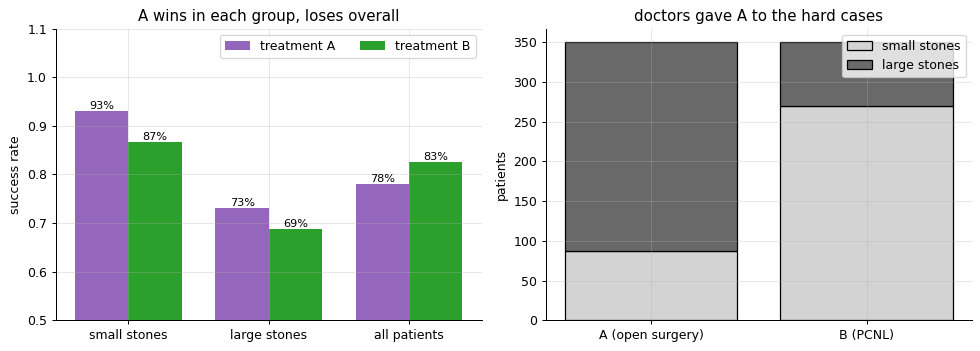

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xs = np.arange(3)
for k, (tr, c) in enumerate([("A", "tab:purple"), ("B", "tab:green")]):
    vals = [rate.loc[tr, "small"], rate.loc[tr, "large"], overall[tr]]
    bars = axes[0].bar(xs + (k - 0.5) * 0.38, vals, 0.38, color=c, label=f"treatment {tr}")
    axes[0].bar_label(bars, labels=[f"{v:.0%}" for v in vals], fontsize=9)
axes[0].set_xticks(xs, ["small stones", "large stones", "all patients"]); axes[0].set_ylim(0.5, 1.1)
axes[0].set_ylabel("success rate"); axes[0].legend(loc="upper right", ncol=2); axes[0].set_title("A wins in each group, loses overall")
for k, tr in enumerate(["A", "B"]):
    axes[1].bar(k, pat.loc[tr, "small"], color="lightgray", edgecolor="k", label="small stones" if k == 0 else None)
    axes[1].bar(k, pat.loc[tr, "large"], bottom=pat.loc[tr, "small"], color="dimgray", edgecolor="k",
                label="large stones" if k == 0 else None)
axes[1].set_xticks([0, 1], ["A (open surgery)", "B (PCNL)"]); axes[1].set_ylabel("patients"); axes[1].legend()
axes[1].set_title("doctors gave A to the hard cases")
plt.tight_layout(); plt.show()

**What is going on.** Large stones are harder to treat (73% and 69% success against 93% and 87% for small ones), and doctors chose open surgery mostly for large stones: 75% of A's patients had one, against 23% of B's. The aggregated comparison mixes "A against B" with "hard cases against easy cases". Stone size is a **confounder**: a common cause of the treatment and of the outcome.

The causal question "what if everybody got A?" keeps the mix of stone sizes of the whole population, $P(z)$, and uses the success rate of A *within* each size. This is the **adjustment formula** (section 3 derives when it is valid):

$$
P(Y = 1 \mid \mathrm{do}(T = t)) = \sum_z P(Y = 1 \mid T = t, Z = z)\, P(Z = z).
$$

An equivalent way to say the same thing is **inverse probability weighting** (section 6): weight each patient by one over the probability of the treatment he received, given his stone size. A patient with a small stone who got A is rare ($87/357$), so he counts for many.

In [4]:
p_z = pat.sum(0) / pat.values.sum()                                 # P(small), P(large) in all 700 patients
do = (rate * p_z).sum(1)                                            # adjustment formula
print(f"P(small) = {p_z['small']:.3f}, P(large) = {p_z['large']:.3f}")
print(f"P(success | do(A)) = {do['A']:.4f}    P(success | do(B)) = {do['B']:.4f}    difference {do['A'] - do['B']:+.4f}")
print(f"P(success | T=A)   = {overall['A']:.4f}    P(success | T=B)   = {overall['B']:.4f}    difference {overall['A'] - overall['B']:+.4f}")

# the same numbers by inverse probability weighting, one row per patient
rows = [(z, tr, s) for _, r in kidney.iterrows() for z, tr, s in
        [(r.stone, r.treatment, 1)] * r.success + [(r.stone, r.treatment, 0)] * (r.patients - r.success)]
pts = pd.DataFrame(rows, columns=["stone", "treatment", "y"])
e_A = pts.groupby("stone")["treatment"].apply(lambda s: np.mean(s == "A"))        # P(T = A | stone)
pts["w"] = np.where(pts.treatment == "A", 1 / pts.stone.map(e_A), 1 / (1 - pts.stone.map(e_A)))
ipw_kidney = {tr: (pts.y * pts.w)[pts.treatment == tr].sum() / len(pts) for tr in ["A", "B"]}
print(f"IPW: A {ipw_kidney['A']:.4f}, B {ipw_kidney['B']:.4f}   (identical to the adjustment formula)")
assert np.isclose(ipw_kidney["A"], do["A"]) and np.isclose(ipw_kidney["B"], do["B"])

P(small) = 0.510, P(large) = 0.490
P(success | do(A)) = 0.8325    P(success | do(B)) = 0.7789    difference +0.0537
P(success | T=A)   = 0.7800    P(success | T=B)   = 0.8257    difference -0.0457
IPW: A 0.8325, B 0.7789   (identical to the adjustment formula)


**What just happened?** The raw data say B is better by 4.6 points (82.6% against 78.0%). Adjusting for stone size reverses the sign: if every patient got A, 83.3% would recover; with B, 77.9%. A is better by 5.4 points. Weighting each patient by $1/P(\text{his treatment} \mid \text{his stone size})$ gives exactly the same numbers, because both methods rebuild a population in which the treatment no longer depends on the stone size.

**Things to notice.**
- No amount of data resolves the paradox by itself. The adjustment is right here because stone size is measured *before* the treatment and influences the choice of treatment. If the third variable were caused by the treatment (say, the blood pressure after the operation), adjusting for it would be wrong and the aggregated table would be the right one. The numbers are identical in both stories; only the **causal structure** tells them apart (section 3).
- In insurance the same trap is everywhere: drivers who take a telematics policy, customers who answer a retention call, claims sent to a fast-track handler are all **selected**, and a raw comparison mixes the effect of the action with the type of person who gets it.

## 2. Potential outcomes and why randomisation works

**The model (Neyman, Rubin).** Each unit $i$ has two **potential outcomes**: $Y_i(1)$, what would happen if treated, and $Y_i(0)$, what would happen if not. The individual effect is $\tau_i = Y_i(1) - Y_i(0)$. We observe only one of them:

$$
Y_i = T_i\, Y_i(1) + (1 - T_i)\, Y_i(0) \qquad \text{(consistency)}.
$$

This is the **fundamental problem of causal inference**: $\tau_i$ is never observed, because the same driver cannot both join and not join the programme in the same year. Causal inference is a missing-data problem, with half of the table missing.

Writing $Y_i(t)$ already assumes **SUTVA** (stable unit treatment value assumption): there is one version of the treatment, and my outcome does not depend on the treatment of others (no interference; it fails for vaccines or for a discount that spreads by word of mouth).

**The running example.** A fictional insurer offers a **telematics programme**: a box in the car, feedback on the driving style, and a discount. We simulate 5,000 drivers with four covariates measured before the decision: age, annual kilometres (thousands), number of claims in the last three years, and urban or rural. The outcome is next year's **claim cost** in euros. Because we simulate, we keep *both* potential outcomes, a privilege no real analyst has. The design:

- Careful drivers join more often: older drivers, drivers with no past claims, low mileage, rural (the propensity $e(x)$ is a logistic function of the four covariates).
- The same drivers are cheaper to insure anyway: young drivers, past claims, high mileage and cities all raise the cost.
- The programme really works: it removes one harsh-braking event per 100 km (worth 30 €) and has a direct effect that is larger for high-mileage drivers, novices and drivers with past claims. So the effect is **heterogeneous**.
- Two more variables are recorded *after* the decision and will be traps: the harsh-braking score (a **mediator**) and whether the customer renewed the next year (a **collider**, it depends on the treatment and on the claim cost).

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def simulate_telematics(n, rng, strength=1.0):
    '''Fictional motor portfolio with BOTH potential outcomes. strength scales the selection into the programme.'''
    age = np.clip(rng.normal(45, 14, n), 18, 85)
    km = np.clip(rng.gamma(4, 3.5, n), 1, 50)                         # thousand km per year
    claims = np.minimum(rng.poisson(0.35 + 0.5 * (age < 25)), 3)      # claims in the last 3 years
    urban = rng.binomial(1, 0.55, n)
    young = np.exp(-(age - 18) / 8)                                   # extra risk of novice drivers
    e = sigmoid(strength * (-0.2 + 0.9 * (age - 45) / 14 - 0.8 * claims - 0.07 * (km - 14) - 0.3 * urban))
    t = rng.binomial(1, e)                                            # careful drivers join more often
    mu0 = 350 + 220 * young + 25 * ((age - 45) / 15) ** 2 + 9 * (km - 14) + 140 * claims + 60 * urban
    b0 = 4 + 0.05 * (km - 14) + 0.6 * claims + 1.5 * young            # harsh-braking events per 100 km
    nb, eps = rng.normal(0, 0.8, n), rng.normal(0, 115, n)
    tau_direct = -2.5 * (km - 14) - 40 * claims - 50 * young          # direct effect of the feedback
    y0 = mu0 + 30 * nb + eps                                          # claim cost (€) without the programme
    y1 = y0 + tau_direct - 30 * 1.0                                   # with it: 1 braking event less, 30 € each
    y = np.where(t == 1, y1, y0)
    brake = b0 + nb - 1.0 * t                                         # mediator, measured after the decision
    renew = rng.binomial(1, sigmoid(1.5 + 1.0 * t - 0.006 * (y - 500)))   # collider: depends on T and Y
    return pd.DataFrame({"age": age, "km": km, "claims": claims, "urban": urban, "T": t, "Y": y,
                         "brake": brake, "renew": renew, "e_true": e, "Y0": y0, "Y1": y1, "tau": y1 - y0})

N = 5000
df = simulate_telematics(N, np.random.default_rng(202))
COVARIATES = ["age", "km", "claims", "urban"]
ATE_TRUE = df.tau.mean()                                   # we know it: we simulated both potential outcomes
ATT_TRUE, ATC_TRUE = df.tau[df["T"] == 1].mean(), df.tau[df["T"] == 0].mean()
ATE_POP = simulate_telematics(400_000, np.random.default_rng(99)).tau.mean()
print(f"{N} drivers, {df['T'].sum()} in the programme ({df['T'].mean():.1%})")
print(f"true ATE (these 5000 drivers) = {ATE_TRUE:.1f} €   population ATE = {ATE_POP:.1f} €")
print(f"true ATT = {ATT_TRUE:.1f} €   true ATC (effect on the non-members) = {ATC_TRUE:.1f} €")

god = df[["age", "km", "claims", "T", "Y0", "Y1", "tau", "Y"]].head(8).round(1)
seen = god.astype(object)
seen.loc[god["T"] == 1, "Y0"] = "?"; seen.loc[god["T"] == 0, "Y1"] = "?"; seen["tau"] = "?"
print("\nGod's view (the simulator):"); print(god.to_string())
print("\nThe analyst's view:"); print(seen.to_string())

5000 drivers, 1847 in the programme (36.9%)
true ATE (these 5000 drivers) = -51.9 €   population ATE = -51.4 €
true ATT = -37.7 €   true ATC (effect on the non-members) = -60.2 €

God's view (the simulator):
    age    km  claims  T     Y0     Y1   tau      Y
0  70.4  11.3       0  1  319.4  296.2 -23.2  296.2
1  34.8  10.8       0  0  450.7  422.5 -28.2  450.7
2  29.8  13.7       0  0  318.7  277.9 -40.8  318.7
3  39.4   8.4       1  1  286.9  227.5 -59.4  227.5
4  28.9  16.9       0  0  788.6  738.3 -50.2  788.6
5  66.1   5.5       0  1  298.3  289.4  -8.9  289.4
6  57.3  20.9       0  0  177.0  129.3 -47.7  177.0
7  53.9  15.3       0  1  293.5  259.6 -33.9  259.6

The analyst's view:
    age    km claims  T     Y0     Y1 tau      Y
0  70.4  11.3      0  1      ?  296.2   ?  296.2
1  34.8  10.8      0  0  450.7      ?   ?  450.7
2  29.8  13.7      0  0  318.7      ?   ?  318.7
3  39.4   8.4      1  1      ?  227.5   ?  227.5
4  28.9  16.9      0  0  788.6      ?   ?  788.6
5  66.1  

**Estimands.** The **ATE** averages $\tau_i$ over everybody; the **ATT** over the treated only. They differ when the effect is heterogeneous and the treated are special. Here the members are careful drivers, for whom the programme does less: −37.7 € against −51.9 € for the whole portfolio (and −60.2 € for the non-members). "Should we make the programme compulsory?" is an ATE question; "was the programme worth it for those who joined?" is an ATT question.

**The naive comparison and its bias.** The obvious estimator compares the average outcome of the two groups. Add and subtract $\mathbb{E}[Y(0) \mid T = 1]$, the cost the members would have had without the programme:

$$
\underbrace{\mathbb{E}[Y \mid T{=}1] - \mathbb{E}[Y \mid T{=}0]}_{\text{naive difference}}
= \underbrace{\mathbb{E}[Y(1) - Y(0) \mid T{=}1]}_{\text{ATT}}
+ \underbrace{\mathbb{E}[Y(0) \mid T{=}1] - \mathbb{E}[Y(0) \mid T{=}0]}_{\text{selection bias}} .
$$

The first step uses consistency: among the treated, $Y = Y(1)$; among the controls, $Y = Y(0)$. The selection bias is the difference between the groups **had nobody been treated**. Careful drivers are cheaper anyway, so it is negative here, and the naive difference exaggerates the effect.

**Why randomisation removes it.** If $T$ is a coin flip, it is independent of the potential outcomes: $(Y(1), Y(0)) \perp T$. Then $\mathbb{E}[Y(0) \mid T{=}1] = \mathbb{E}[Y(0) \mid T{=}0] = \mathbb{E}[Y(0)]$, the selection bias is zero, the ATT equals the ATE, and

$$
\mathbb{E}[Y \mid T{=}1] - \mathbb{E}[Y \mid T{=}0] = \mathbb{E}[Y(1) \mid T{=}1] - \mathbb{E}[Y(0) \mid T{=}0] = \mathbb{E}[Y(1)] - \mathbb{E}[Y(0)] = \text{ATE}. \qquad\blacksquare
$$

This is why the A/B test is the gold standard: it needs no model and no assumption about the covariates. Below we check the decomposition on the observed data, then replay history 500 times on the same 5,000 drivers, once with a coin flip and once with the real (confounded) assignment.

In [6]:
t_obs, y_obs = df["T"].to_numpy(), df["Y"].to_numpy()
naive = y_obs[t_obs == 1].mean() - y_obs[t_obs == 0].mean()
sel_bias = df.Y0[t_obs == 1].mean() - df.Y0[t_obs == 0].mean()
print(f"naive difference = {naive:.1f} €")
print(f"   = ATT {ATT_TRUE:.1f} + selection bias {sel_bias:.1f}   (sum {ATT_TRUE + sel_bias:.1f})")
assert np.isclose(naive, ATT_TRUE + sel_bias)          # an identity, exact in every sample

rng_exp = np.random.default_rng(1)
naive_rand, naive_conf = [], []
for _ in range(500):
    for t_, out in ((rng_exp.binomial(1, 0.5, N), naive_rand),            # A/B test: a coin flip
                    (rng_exp.binomial(1, df.e_true), naive_conf)):        # real life: careful drivers self-select
        y_ = np.where(t_ == 1, df.Y1, df.Y0)
        out.append(y_[t_ == 1].mean() - y_[t_ == 0].mean())
naive_rand, naive_conf = np.array(naive_rand), np.array(naive_conf)
print(f"\nrandomised assignment: mean of 500 naive estimates {naive_rand.mean():.1f} € (sd {naive_rand.std():.1f})"
      f"   true ATE {ATE_TRUE:.1f}")
print(f"confounded assignment: mean of 500 naive estimates {naive_conf.mean():.1f} € (sd {naive_conf.std():.1f})")
assert abs(naive_rand.mean() - ATE_TRUE) < 4 * naive_rand.std() / np.sqrt(500)     # unbiased
assert naive_conf.mean() < ATE_TRUE - 40                                           # badly biased

naive difference = -120.9 €
   = ATT -37.7 + selection bias -83.1   (sum -120.9)



randomised assignment: mean of 500 naive estimates -52.1 € (sd 4.8)   true ATE -51.9
confounded assignment: mean of 500 naive estimates -123.8 € (sd 3.9)


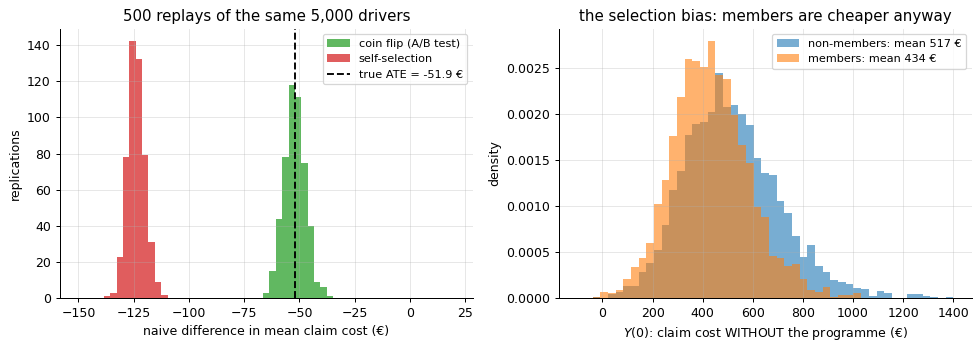

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-150, 20, 60)
axes[0].hist(naive_rand, bins, color="tab:green", alpha=0.75, label="coin flip (A/B test)")
axes[0].hist(naive_conf, bins, color="tab:red", alpha=0.75, label="self-selection")
axes[0].axvline(ATE_TRUE, color="k", ls="--", label=f"true ATE = {ATE_TRUE:.1f} €")
axes[0].set_xlabel("naive difference in mean claim cost (€)"); axes[0].set_ylabel("replications")
axes[0].set_title("500 replays of the same 5,000 drivers"); axes[0].legend(fontsize=9)
b2 = np.linspace(-100, 1400, 50)
axes[1].hist(df.Y0[t_obs == 0], b2, density=True, alpha=0.6, color=C_CTRL, label=f"non-members: mean {df.Y0[t_obs == 0].mean():.0f} €")
axes[1].hist(df.Y0[t_obs == 1], b2, density=True, alpha=0.6, color=C_TREAT, label=f"members: mean {df.Y0[t_obs == 1].mean():.0f} €")
axes[1].set_xlabel("$Y(0)$: claim cost WITHOUT the programme (€)"); axes[1].set_ylabel("density")
axes[1].set_title("the selection bias: members are cheaper anyway"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** On the observed data the naive difference is −120.9 €: members cost 121 € less than non-members. The true effect of the programme is −51.9 € on average (−37.7 € for its members). The decomposition is exact: −120.9 = −37.7 (ATT) − 83.1 (selection bias). More than two thirds of the raw difference is not caused by the programme at all: it is the difference between careful and less careful drivers, visible in the right panel as the gap between the two $Y(0)$ distributions, which no real analyst can draw (mean $Y(0)$: 434 € for members, 517 € for non-members).

Under a coin flip the 500 naive estimates are centred on the truth (mean −52.1 €, sd 4.8). Under self-selection they are centred on −123.8 €, and more data would not help: the bias does not shrink with $n$, only the spread does.

**The assumptions we need without randomisation.** When we cannot run an A/B test (it is too slow, too expensive, unethical, or the data are historical), we replace randomisation by assumptions:

- **Ignorability** (unconfoundedness, no unmeasured confounders): $(Y(1), Y(0)) \perp T \mid X$. Within drivers with the same covariates, joining is as good as random. Untestable from the data: it is a claim about variables we did *not* measure.
- **Positivity** (overlap): $0 < e(x) < 1$ for every $x$. Every kind of driver has some chance of each treatment, otherwise there is nobody to compare with. Testable, and section 5 tests it.
- **Consistency and SUTVA**, as above.

Under these, $\mathbb{E}[Y(t) \mid X] = \mathbb{E}[Y(t) \mid T = t, X] = \mathbb{E}[Y \mid T = t, X] = \mu_t(X)$, and everything in sections 4 to 6 follows from this one line.

## 3. Causal graphs: junctions, colliders and the backdoor criterion

A **causal DAG** (directed acyclic graph, Pearl) draws an arrow $A \to B$ when $A$ is a direct cause of $B$. It turns the vague "control for confounders" into rules. Every path between two variables is built from three kinds of **junctions**:

| junction | shape | example | $X$ and $Y$ marginally | conditioning on $Z$ |
|---|---|---|---|---|
| chain | $X \to Z \to Y$ | telematics → braking → claims | dependent | **blocks** the path |
| fork | $X \leftarrow Z \to Y$ | joining ← age → claims | dependent | **blocks** the path |
| collider | $X \to Z \leftarrow Y$ | telematics → renewal ← claims | independent | **opens** the path |

A path is **blocked** by a set $S$ if it contains a chain or fork whose middle node is in $S$, or a collider such that neither it nor any of its descendants is in $S$. If every path between $X$ and $Y$ is blocked, they are **d-separated** given $S$, and then independent given $S$ in every distribution that the DAG can generate.

We simulate each junction with Gaussian noise (all coefficients 1) and measure the correlation of $X$ and $Y$ before and after conditioning on $Z$. "Conditioning" is done two ways: the **partial correlation** (correlate the residuals of $X$ and $Y$ after regressing each on $Z$), and the correlation inside a thin slice $|Z| < 0.25$, which is what the slides draw.

In [8]:
rng_j = np.random.default_rng(2)
n_j = 5000
def partial_corr(x, y, z):
    '''Correlation of x and y after removing the linear effect of z from both.'''
    Z = np.column_stack([np.ones_like(z), z])
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return np.corrcoef(rx, ry)[0, 1]

e1, e2, e3 = rng_j.normal(size=(3, n_j))
junctions = {}
X_ = e1; Z_ = X_ + e2; Y_ = Z_ + e3; junctions["chain   X → Z → Y"] = (X_, Y_, Z_)
Z_ = e1; X_ = Z_ + e2; Y_ = Z_ + e3; junctions["fork    X ← Z → Y"] = (X_, Y_, Z_)
X_ = e1; Y_ = e2; Z_ = X_ + Y_ + e3; junctions["collider X → Z ← Y"] = (X_, Y_, Z_)
theory = {"chain": (1 / np.sqrt(3), 0), "fork": (0.5, 0), "collider": (0, -0.5)}
print(f"{'junction':22s} {'corr(X,Y)':>10s} {'theory':>7s} {'partial | Z':>12s} {'theory':>7s} {'in slice |Z|<0.25':>18s}")
for name, (x, y, z) in junctions.items():
    c, pc = np.corrcoef(x, y)[0, 1], partial_corr(x, y, z)
    s = np.abs(z) < 0.25
    th = theory[name.split()[0]]
    print(f"{name:22s} {c:10.3f} {th[0]:7.3f} {pc:12.3f} {th[1]:7.3f} {np.corrcoef(x[s], y[s])[0, 1]:12.3f} (n={s.sum()})")
    assert abs(c - th[0]) < 0.05 and abs(pc - th[1]) < 0.05

junction                corr(X,Y)  theory  partial | Z  theory  in slice |Z|<0.25
chain   X → Z → Y           0.578   0.577        0.012   0.000        0.017 (n=701)
fork    X ← Z → Y           0.500   0.500       -0.001   0.000       -0.013 (n=977)
collider X → Z ← Y         -0.014   0.000       -0.516  -0.500       -0.541 (n=550)


The theoretical values follow from the covariances. In the chain, $\operatorname{Var}(Z) = 2$, $\operatorname{Var}(Y) = 3$ and $\operatorname{Cov}(X, Y) = 1$, so $\rho = 1/\sqrt 3 = 0.577$. In the collider, $X$ and $Y$ are independent, but given $Z$ the conditional covariance is $\operatorname{Cov}(X, Y) - \operatorname{Cov}(X, Z)\operatorname{Cov}(Y, Z)/\operatorname{Var}(Z) = 0 - 1 \cdot 1/3$ and each conditional variance is $1 - 1/3$, so the partial correlation is $(-1/3)/(2/3) = -0.5$: knowing the sum, a large $X$ "explains away" $Y$.

**Collider bias in real life.** Hollywood actors are selected on talent *and* looks. Suppose the two are independent in the population and a person becomes an actor when talent + looks > 1.5 (about the top 14%). Among actors the two traits become negatively correlated, although nothing links them. The same mechanism (Berkson's paradox) makes two diseases look negatively associated among hospitalised patients, and makes "claims among customers who renewed" a biased sample, as section 4 shows.

actors: 14.1% of the population
corr(talent, looks): everybody +0.015   among actors -0.636


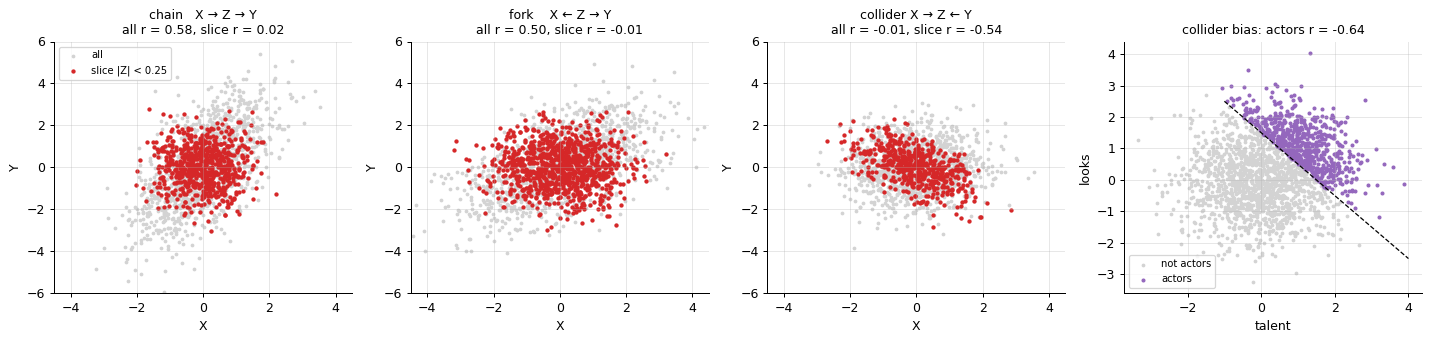

In [9]:
talent, looks = np.random.default_rng(3).normal(size=(2, n_j))
actor = talent + looks > 1.5
print(f"actors: {actor.mean():.1%} of the population")
print(f"corr(talent, looks): everybody {np.corrcoef(talent, looks)[0, 1]:+.3f}   among actors {np.corrcoef(talent[actor], looks[actor])[0, 1]:+.3f}")
assert np.corrcoef(talent[actor], looks[actor])[0, 1] < -0.4

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))
for ax, (name, (x, y, z)) in zip(axes[:3], junctions.items()):
    s = np.abs(z) < 0.25
    ax.scatter(x[::4], y[::4], s=4, color="lightgray", label="all")
    ax.scatter(x[s], y[s], s=6, color="tab:red", label="slice |Z| < 0.25")
    ax.set_title(f"{name}\nall r = {np.corrcoef(x, y)[0, 1]:.2f}, slice r = {np.corrcoef(x[s], y[s])[0, 1]:.2f}", fontsize=10)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_xlim(-4.5, 4.5); ax.set_ylim(-6, 6)
axes[0].legend(fontsize=8, loc="upper left")
axes[3].scatter(talent[~actor][::3], looks[~actor][::3], s=4, color="lightgray", label="not actors")
axes[3].scatter(talent[actor], looks[actor], s=5, color="tab:purple", label="actors")
axes[3].plot([-1, 4], [2.5, -2.5], "k--", lw=1)
axes[3].set_title(f"collider bias: actors r = {np.corrcoef(talent[actor], looks[actor])[0, 1]:.2f}", fontsize=10)
axes[3].set_xlabel("talent"); axes[3].set_ylabel("looks"); axes[3].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**The backdoor criterion.** To estimate the effect of $T$ on $Y$ we must block every **backdoor path** (a path that starts with an arrow *into* $T$, such as $T \leftarrow \text{age} \to Y$) and leave the causal paths alone. A set $S$ satisfies the **backdoor criterion** if

1. no variable in $S$ is a descendant of $T$, and
2. $S$ blocks every backdoor path between $T$ and $Y$.

Then $S$ is a sufficient adjustment set: ignorability holds given $S$, and

$$
P(Y \mid \mathrm{do}(T = t)) = \sum_s P(Y \mid T = t, S = s)\, P(S = s), \qquad \mathbb{E}[Y(t)] = \mathbb{E}_S\big[\mu_t(S)\big].
$$

Below is the DAG of our simulator (it is the truth here; in a real study it is the analyst's assumption, drawn *before* looking at the outcome). We list all paths from $T$ to $Y$ with a from-scratch implementation of the blocking rules, and check the backdoor criterion for several candidate sets against NetworkX's d-separation test on the graph with $T$'s outgoing arrows removed.

In [10]:
dag = nx.DiGraph([("age", "claims"), ("age", "T"), ("age", "Y"), ("claims", "T"), ("claims", "Y"),
                  ("km", "T"), ("km", "Y"), ("urban", "T"), ("urban", "Y"),
                  ("age", "brake"), ("claims", "brake"), ("km", "brake"),
                  ("T", "brake"), ("brake", "Y"), ("T", "Y"), ("T", "renew"), ("Y", "renew")])
assert nx.is_directed_acyclic_graph(dag)

def is_blocked(G, path, S):
    '''From scratch: is this path (a list of nodes) blocked by the set S?'''
    for a, m, b in zip(path, path[1:], path[2:]):
        if G.has_edge(a, m) and G.has_edge(b, m):              # collider a -> m <- b
            if m not in S and not (nx.descendants(G, m) & S):
                return True
        elif m in S:                                            # chain or fork with its middle node in S
            return True
    return False

def backdoor_ok(G, t, y, S):
    '''Backdoor criterion, from scratch: no descendant of t in S, every backdoor path blocked.'''
    if S & nx.descendants(G, t):
        return False
    paths = nx.all_simple_paths(G.to_undirected(), t, y)
    return all(is_blocked(G, p, S) for p in paths if G.has_edge(p[1], t))

def backdoor_ok_networkx(G, t, y, S):
    G_bd = G.copy(); G_bd.remove_edges_from(list(G.out_edges(t)))   # keep only the backdoor paths
    return not (S & nx.descendants(G, t)) and (getattr(nx, "is_d_separator", None) or nx.d_separated)(G_bd, {t}, {y}, S)

all_paths = list(nx.all_simple_paths(dag.to_undirected(), "T", "Y"))
arrow = lambda a, b: "→" if dag.has_edge(a, b) else "←"
fmt = lambda p: " ".join(p[0:1] + [f"{arrow(a, b)} {b}" for a, b in zip(p, p[1:])])
back = [p for p in all_paths if dag.has_edge(p[1], "T")]
causal = [p for p in all_paths if all(dag.has_edge(a, b) for a, b in zip(p, p[1:]))]
print(f"{len(all_paths)} paths between T and Y: {len(causal)} causal, {len(back)} backdoor, "
      f"{len(all_paths) - len(causal) - len(back)} other (they start T → and meet a collider)")
for p in causal: print("   causal:  ", fmt(p))
for p in back[:4]: print("   backdoor:", fmt(p))
print("    ...")

candidates = {"{} (naive)": set(), "{age, km, claims, urban}": {"age", "km", "claims", "urban"},
              "{km, claims, urban} (no age)": {"km", "claims", "urban"},
              "{age, km, claims, urban, brake}": {"age", "km", "claims", "urban", "brake"},
              "{age, km, claims, urban, renew}": {"age", "km", "claims", "urban", "renew"}}
print(f"\n{'adjustment set':34s} {'open backdoor':>13s} {'blocked causal':>15s} {'backdoor ok':>12s} {'networkx':>9s}")
for name, S in candidates.items():
    n_open = sum(not is_blocked(dag, p, S) for p in back)
    n_cblk = sum(is_blocked(dag, p, S) for p in causal)
    ok, ok_nx = backdoor_ok(dag, "T", "Y", S), backdoor_ok_networkx(dag, "T", "Y", S)
    print(f"{name:34s} {n_open:>8d}/{len(back):<4d} {n_cblk:>10d}/{len(causal):<4d} {str(ok):>12s} {str(ok_nx):>9s}")
    assert ok == ok_nx

29 paths between T and Y: 2 causal, 21 backdoor, 6 other (they start T → and meet a collider)
   causal:   T → brake → Y
   causal:   T → Y
   backdoor: T ← age → claims → Y
   backdoor: T ← age → claims → brake ← km → Y
   backdoor: T ← age → claims → brake → Y
   backdoor: T ← age → Y
    ...

adjustment set                     open backdoor  blocked causal  backdoor ok  networkx
{} (naive)                               11/21            0/2           False     False
{age, km, claims, urban}                  0/21            0/2            True      True
{km, claims, urban} (no age)              2/21            0/2           False     False
{age, km, claims, urban, brake}           0/21            1/2           False     False
{age, km, claims, urban, renew}           0/21            0/2           False     False


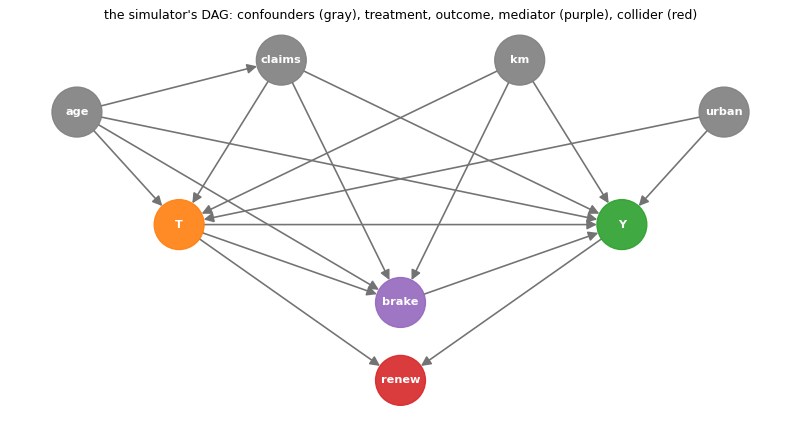

In [11]:
pos = {"age": (0, 2.2), "claims": (1.2, 2.8), "km": (2.6, 2.8), "urban": (3.8, 2.2), "T": (0.6, 0.9),
       "brake": (1.9, 0.0), "Y": (3.2, 0.9), "renew": (1.9, -0.9)}
role = {"age": "tab:gray", "claims": "tab:gray", "km": "tab:gray", "urban": "tab:gray", "T": C_TREAT,
        "Y": "tab:green", "brake": "tab:purple", "renew": "tab:red"}
fig, ax = plt.subplots(figsize=(9, 4.8))
nx.draw_networkx_edges(dag, pos, ax=ax, arrowsize=16, node_size=1600, edge_color="0.45", width=1.3)
nx.draw_networkx_nodes(dag, pos, ax=ax, node_size=1600, node_color=[role[v] for v in dag], alpha=0.9)
nx.draw_networkx_labels(dag, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")
ax.set_title("the simulator's DAG: confounders (gray), treatment, outcome, mediator (purple), collider (red)", fontsize=10)
ax.axis("off"); plt.tight_layout(); plt.show()

**What just happened?** There are 29 paths between $T$ and $Y$ in this small graph. Two are causal ($T \to Y$ and $T \to \text{brake} \to Y$), 21 are backdoor paths through the confounders, and the rest leave $T$ forwards and run into a collider ($T \to \text{brake} \leftarrow \text{age} \to Y$, for example) so they are blocked as long as we leave the collider alone. The from-scratch rules and NetworkX agree on every candidate set:

- Adjusting for nothing leaves 11 of the 21 backdoor paths open (the other 10 pass through the collider brake, which blocks them): the naive difference is biased (section 2).
- $\{\text{age, km, claims, urban}\}$ blocks them all and touches no descendant of $T$: a valid adjustment set.
- Dropping age leaves 2 backdoor paths open: $T \leftarrow \text{age} \to Y$ and $T \leftarrow \text{age} \to \text{brake} \to Y$.
- Adding **brake** blocks one of the two causal paths: we would estimate only the direct effect. This is **over-control**, a classic **bad control**: a mediator is a consequence of the treatment.
- Adding **renew** conditions on a descendant of $T$ and opens the collider path $T \to \text{renew} \leftarrow Y$: **collider (selection) bias**.

The rule of thumb that follows: adjust for **pre-treatment** common causes; never adjust for variables measured after the treatment that it may have changed. "Put every available variable in the model", the default habit of predictive modelling, is wrong for causal questions.

## 4. Regression adjustment and bad controls

Under ignorability and positivity, section 2 gave $\mathbb{E}[Y(t) \mid X] = \mu_t(X)$. Averaging over the covariates of the population:

$$
\text{ATE} = \mathbb{E}_X\big[\mu_1(X) - \mu_0(X)\big] \;\approx\; \frac{1}{n}\sum_{i=1}^{n}\big(\hat\mu_1(x_i) - \hat\mu_0(x_i)\big).
$$

This is **regression adjustment**, also called **g-computation** or the plug-in estimator: fit one outcome model per arm, predict *both* outcomes for every driver, average the difference. It is the continuous version of the adjustment formula of section 1 (a sum over strata becomes an average over the sample). Its weak point is the model: if $\hat\mu_t$ is wrong, the estimate is wrong, and $\hat\mu_1$ must extrapolate to drivers unlike those who joined.

Our outcome model is a linear regression with a cubic spline in age (novice drivers are expensive, the curve is far from linear) and linear terms in km, claims and urban. For comparison we also fit the textbook regression $Y \sim T + X$ with one coefficient for $T$: it assumes a constant effect and a linear age profile.

In [12]:
X_all = df[COVARIATES].to_numpy(float)

def fit_outcome_models(X, t, y):
    '''mu_1 and mu_0 for every row: spline in the first column (age), linear in the others, one model per arm.'''
    spline = SplineTransformer(n_knots=5, degree=3, knots="quantile", include_bias=False).fit(X[:, :1])
    F = np.column_stack([spline.transform(X[:, :1]), X[:, 1:]])
    mu1 = LinearRegression().fit(F[t == 1], y[t == 1]).predict(F)
    mu0 = LinearRegression().fit(F[t == 0], y[t == 0]).predict(F)
    return mu1, mu0

def g_computation(X, t, y):
    mu1, mu0 = fit_outcome_models(X, t, y)
    return np.mean(mu1 - mu0)

ols = LinearRegression().fit(np.column_stack([t_obs, X_all]), y_obs)
est_ra = g_computation(X_all, t_obs, y_obs)
mu1_hat, mu0_hat = fit_outcome_models(X_all, t_obs, y_obs)
print(f"true ATE                                 {ATE_TRUE:7.1f} €")
print(f"naive difference                         {naive:7.1f} €")
print(f"OLS  Y ~ T + X, coefficient of T         {ols.coef_[0]:7.1f} €")
print(f"g-computation (splines, one model/arm)   {est_ra:7.1f} €")
print(f"   its ATT version (treated rows only)   {np.mean((mu1_hat - mu0_hat)[t_obs == 1]):7.1f} €   true ATT {ATT_TRUE:.1f}")
assert abs(est_ra - ATE_TRUE) < 8 and abs(naive - ATE_TRUE) > 40

true ATE                                   -51.9 €
naive difference                          -120.9 €
OLS  Y ~ T + X, coefficient of T           -33.8 €
g-computation (splines, one model/arm)     -51.1 €
   its ATT version (treated rows only)     -36.6 €   true ATT -37.7


**Bad controls, with numbers.** The DAG of section 3 predicts two failures. We now commit them on purpose:

- **Over-control**: add the harsh-braking score to the covariates. The model then compares members and non-members *with the same braking*, which removes the part of the effect that goes through braking ($-30$ € per driver by construction). The estimate should drop to about the direct effect, whose true mean we also know.
- **Selection on a collider**: analyse only the customers who renewed. Renewal depends on the treatment (members renew more) and on the outcome (expensive drivers leave, or are not renewed), so among renewers $T$ and $Y$ are linked by a non-causal path.

renewal rate: members 94.2%, non-members 76.7%
adjust for {age, km, claims, urban}              -51.1 €   (true ATE -51.9)
   + brake (a mediator)                         -20.0 €   (true direct effect -21.9)
   only customers who renewed (a collider)      -38.8 €   (true ATE of the renewers -46.7)


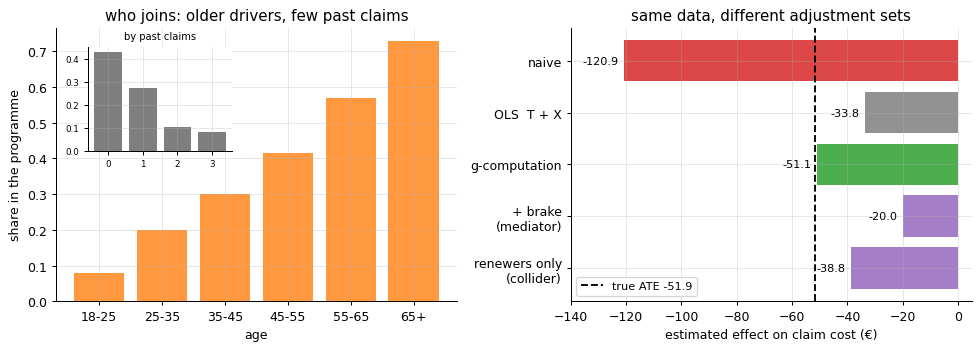

In [13]:
direct_true = (df.tau + 30).mean()                    # the effect that does not go through braking
est_brake = g_computation(df[COVARIATES + ["brake"]].to_numpy(float), t_obs, y_obs)
ren = df.renew.to_numpy() == 1
est_renew = g_computation(X_all[ren], t_obs[ren], y_obs[ren])
print(f"renewal rate: members {df.renew[t_obs == 1].mean():.1%}, non-members {df.renew[t_obs == 0].mean():.1%}")
print(f"adjust for {{age, km, claims, urban}}            {est_ra:7.1f} €   (true ATE {ATE_TRUE:.1f})")
print(f"   + brake (a mediator)                       {est_brake:7.1f} €   (true direct effect {direct_true:.1f})")
print(f"   only customers who renewed (a collider)    {est_renew:7.1f} €   (true ATE of the renewers {df.tau[ren].mean():.1f})")
assert abs(est_brake - direct_true) < 8 and est_renew - df.tau[ren].mean() > 5

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
age_bins = pd.cut(df.age, [17, 25, 35, 45, 55, 65, 86])
share = df.groupby(age_bins, observed=True)["T"].mean()
axes[0].bar(range(len(share)), share.values, color=C_TREAT, alpha=0.8, label="by age group")
axes[0].set_xticks(range(len(share)), ["18-25", "25-35", "35-45", "45-55", "55-65", "65+"])
axes[0].set_ylabel("share in the programme"); axes[0].set_xlabel("age")
cl = df.groupby("claims")["T"].mean()
ax2 = axes[0].inset_axes([0.08, 0.55, 0.36, 0.38])
ax2.bar(cl.index, cl.values, color="tab:gray"); ax2.set_title("by past claims", fontsize=8); ax2.tick_params(labelsize=7)
axes[0].set_title("who joins: older drivers, few past claims")
names = ["naive", "OLS  T + X", "g-computation", "+ brake\n(mediator)", "renewers only\n(collider)"]
vals = [naive, ols.coef_[0], est_ra, est_brake, est_renew]
cols = ["tab:red", "tab:gray", "tab:green", "tab:purple", "tab:purple"]
axes[1].barh(range(5), vals, color=cols, alpha=0.85)
for k, v in enumerate(vals):
    axes[1].text(v - 2, k, f"{v:.1f}", va="center", ha="right", fontsize=9)
axes[1].axvline(ATE_TRUE, color="k", ls="--", label=f"true ATE {ATE_TRUE:.1f}")
axes[1].set_yticks(range(5), names); axes[1].invert_yaxis(); axes[1].set_xlim(-140, 5)
axes[1].set_xlabel("estimated effect on claim cost (€)"); axes[1].legend(loc="lower left", fontsize=9)
axes[1].set_title("same data, different adjustment sets")
plt.tight_layout(); plt.show()

**What just happened?** With the right adjustment set and a flexible outcome model, g-computation gives −51.1 € against a true ATE of −51.9 €, from data whose raw difference was −120.9 €. Restricted to the members, the same predictions estimate the ATT: −36.6 € (true −37.7 €). The one-coefficient regression gives −33.8 €: it is misspecified twice (a straight line in age, and a single effect for drivers whose effects differ), and when effects vary its coefficient is a weighted average that favours the drivers with $e(x)$ near 0.5, not the ATE.

The bad controls fail exactly as the DAG predicts. Adding the braking score gives −20.0 €, close to the direct effect (−21.9 €): the 30 € that travel through braking are "controlled away". Restricting to renewers gives −38.8 €, biased towards zero by 7.9 € even with respect to the renewers' own true effect (−46.7 €): expensive non-members left, so the non-members who remain look cheaper than they are. In a real portfolio the renewers are the only customers whose next-year claims we see, so this bias is very easy to commit.

## 5. Propensity scores: overlap, balance and matching

**The propensity score** $e(x) = P(T = 1 \mid X = x)$ compresses all covariates into one number. Rosenbaum and Rubin (1983) proved that it is a **balancing score**: among units with the same $e(x)$, the covariates have the same distribution in both arms, $X \perp T \mid e(X)$. Proof in one line: $P(T = 1 \mid X, e(X)) = e(X)$, which does not depend on $X$ beyond $e(X)$, so $P(T = 1 \mid X, e(X)) = P(T = 1 \mid e(X))$. Consequently, if ignorability holds given $X$, it also holds given $e(X)$ alone: we can match, stratify or weight on a single number.

In practice $e(x)$ is unknown and estimated, usually with a logistic regression (or boosting, carefully calibrated). Two diagnostics come first:

- **Overlap**: the distributions of $\hat e(x)$ in the two arms should share their support. Where one arm has no units, there is nobody to compare with, and every method extrapolates.
- **Balance**: after matching or weighting, the **standardised mean difference** of every covariate, $\text{SMD} = (\bar x_1 - \bar x_0)/\sqrt{(s_1^2 + s_0^2)/2}$, should be small (a common rule: $|\text{SMD}| < 0.1$).

In [14]:
def fit_propensity(X, t):
    '''Logistic regression on standardised covariates (almost no penalty).'''
    sc = StandardScaler().fit(X)
    return LogisticRegression(C=1e6, max_iter=1000).fit(sc.transform(X), t).predict_proba(sc.transform(X))[:, 1]

e_hat = fit_propensity(X_all, t_obs)
print(f"estimated propensity: min {e_hat.min():.4f}, max {e_hat.max():.3f}; "
      f"corr with the true e(x) {np.corrcoef(e_hat, df.e_true)[0, 1]:.4f}, mean |error| {np.abs(e_hat - df.e_true).mean():.4f}")
for lo, hi in [(0, 0.05), (0.05, 0.95), (0.95, 1)]:
    m = (e_hat >= lo) & (e_hat < hi)
    print(f"   e in [{lo:.2f}, {hi:.2f}): {m.sum():5d} drivers ({t_obs[m].sum()} members)")

def smd(x, t, w=None):
    '''Standardised mean difference of one covariate, optionally weighted.'''
    w = np.ones_like(x, dtype=float) if w is None else w
    m1, m0 = np.average(x[t == 1], weights=w[t == 1]), np.average(x[t == 0], weights=w[t == 0])
    v1 = np.average((x[t == 1] - m1) ** 2, weights=w[t == 1]); v0 = np.average((x[t == 0] - m0) ** 2, weights=w[t == 0])
    return (m1 - m0) / np.sqrt((v1 + v0) / 2)

def match_ate(e, t, y):
    '''1-nearest-neighbour matching on logit(e), with replacement. Returns ATE, ATT and the matches.'''
    lg = np.log(e / (1 - e)).reshape(-1, 1)
    it, ic = np.flatnonzero(t == 1), np.flatnonzero(t == 0)
    for_t = ic[NearestNeighbors(n_neighbors=1).fit(lg[ic]).kneighbors(lg[it], return_distance=False)[:, 0]]
    for_c = it[NearestNeighbors(n_neighbors=1).fit(lg[it]).kneighbors(lg[ic], return_distance=False)[:, 0]]
    y1, y0 = y.astype(float).copy(), y.astype(float).copy()
    y0[it] = y[for_t]                    # a treated driver's missing Y(0): the outcome of the closest control
    y1[ic] = y[for_c]                    # a control's missing Y(1): the outcome of the closest treated driver
    return np.mean(y1 - y0), np.mean((y1 - y0)[it]), for_t, for_c

est_match, att_match, for_t, for_c = match_ate(e_hat, t_obs, y_obs)
it = np.flatnonzero(t_obs == 1)
lg = np.log(e_hat / (1 - e_hat))
print(f"\nmatching: ATE {est_match:.1f} € (true {ATE_TRUE:.1f}), ATT {att_match:.1f} € (true {ATT_TRUE:.1f})")
print(f"   mean |logit gap| of a treated driver and its match: {np.abs(lg[it] - lg[for_t]).mean():.4f}")
print(f"   {len(np.unique(for_t))} distinct controls serve as matches for {len(it)} members; "
      f"the busiest control is used {np.bincount(for_t).max()} times")
w_ate = np.where(t_obs == 1, 1 / e_hat, 1 / (1 - e_hat))
matched = np.concatenate([it, for_t]); t_m = np.concatenate([np.ones(len(it), int), np.zeros(len(it), int)])
bal = pd.DataFrame({"raw": [smd(df[c].to_numpy(float), t_obs) for c in COVARIATES],
                    "matched (ATT)": [smd(df[c].to_numpy(float)[matched], t_m) for c in COVARIATES],
                    "IPW-weighted": [smd(df[c].to_numpy(float), t_obs, w_ate) for c in COVARIATES]}, index=COVARIATES)
print("\nstandardised mean differences (members minus non-members):"); print(bal.round(3).to_string())
assert (bal["raw"].abs() > 0.1).sum() >= 2 and (bal["IPW-weighted"].abs() < 0.1).all() and (bal["matched (ATT)"].abs() < 0.1).all()

estimated propensity: min 0.0049, max 0.941; corr with the true e(x) 0.9986, mean |error| 0.0104
   e in [0.00, 0.05):   197 drivers (6 members)
   e in [0.05, 0.95):  4803 drivers (1841 members)
   e in [0.95, 1.00):     0 drivers (0 members)

matching: ATE -47.8 € (true -51.9), ATT -30.9 € (true -37.7)
   mean |logit gap| of a treated driver and its match: 0.0038
   1023 distinct controls serve as matches for 1847 members; the busiest control is used 18 times

standardised mean differences (members minus non-members):
          raw  matched (ATT)  IPW-weighted
age     0.800          0.022        -0.009
km     -0.378          0.048        -0.029
claims -0.445          0.000         0.010
urban  -0.070         -0.033         0.010


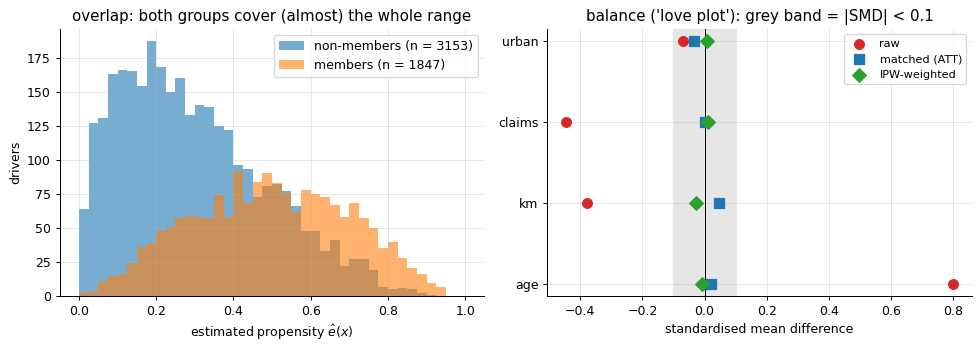

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
b = np.linspace(0, 1, 41)
axes[0].hist(e_hat[t_obs == 0], b, alpha=0.6, color=C_CTRL, label=f"non-members (n = {(t_obs == 0).sum()})")
axes[0].hist(e_hat[t_obs == 1], b, alpha=0.6, color=C_TREAT, label=f"members (n = {(t_obs == 1).sum()})")
axes[0].set_xlabel(r"estimated propensity $\hat e(x)$"); axes[0].set_ylabel("drivers"); axes[0].legend()
axes[0].set_title("overlap: both groups cover (almost) the whole range")
yy = np.arange(len(COVARIATES))
for col, mk, c in [("raw", "o", "tab:red"), ("matched (ATT)", "s", "tab:blue"), ("IPW-weighted", "D", "tab:green")]:
    axes[1].scatter(bal[col], yy, marker=mk, s=60, color=c, label=col, zorder=3)
axes[1].axvspan(-0.1, 0.1, color="0.9", zorder=0); axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_yticks(yy, COVARIATES); axes[1].set_xlabel("standardised mean difference"); axes[1].legend(fontsize=9)
axes[1].set_title("balance ('love plot'): grey band = |SMD| < 0.1")
plt.tight_layout(); plt.show()

**What just happened?** The logistic propensity model recovers the true $e(x)$ almost perfectly (correlation 0.9986), as it should: the simulator uses a logistic model in the same covariates. In a real study, it is only as good as the covariates we have.

Overlap is decent but not perfect: 197 drivers have $\hat e < 0.05$ (young, high-mileage drivers with past claims almost never join; only 6 of them did), and nobody has $\hat e \ge 0.95$ (the largest is 0.941). Before adjustment the members are much older (SMD of age +0.80), drive less (−0.38) and have fewer past claims (−0.45). Matching each member with the non-member of closest propensity, and weighting by $1/\hat e$, both bring every SMD below 0.1.

Matching gives −47.8 € for the ATE and −30.9 € for the ATT (true values −51.9 and −37.7): unbiased in principle, noisy in practice. With replacement, 1,023 distinct controls serve as matches for 1,847 members, and the busiest control is reused 18 times: one non-member stands in for 18 members who look like him, and carries that much weight. Matching is easy to explain to a business audience ("we compared each member with a non-member who looked just like him"), but it discards information and its standard errors need care (section 7).

## 6. Inverse probability weighting and doubly robust estimation

**IPW (Horvitz–Thompson).** Weight each treated unit by $1/e(X)$ and each control by $1/(1 - e(X))$:

$$
\hat\tau_{\text{IPW}} = \frac{1}{n}\sum_i \frac{T_i Y_i}{e(x_i)} - \frac{1}{n}\sum_i \frac{(1 - T_i) Y_i}{1 - e(x_i)} .
$$

**Why it is unbiased.** Take the first term. By consistency $T Y = T\, Y(1)$, so, conditioning on $X$,

$$
\mathbb{E}\Big[\frac{T\,Y}{e(X)}\Big] = \mathbb{E}\Big[\frac{\mathbb{E}[T\,Y(1) \mid X]}{e(X)}\Big]
= \mathbb{E}\Big[\frac{\mathbb{E}[T \mid X]\;\mathbb{E}[Y(1) \mid X]}{e(X)}\Big]
= \mathbb{E}\Big[\frac{e(X)\,\mu^{(1)}(X)}{e(X)}\Big] = \mathbb{E}[Y(1)],
$$

where the second equality is ignorability ($T \perp Y(1) \mid X$) and $\mu^{(1)}(X) = \mathbb{E}[Y(1) \mid X]$. Positivity is needed to divide by $e(X)$. The same argument gives $\mathbb{E}[Y(0)]$ for the second term. $\blacksquare$ Intuition: a member with $e = 0.1$ stands for ten drivers like him, nine of whom did not join; the weighted sample is a **pseudo-population** in which $T$ is independent of $X$, as in a randomised trial.

**Stabilised weights.** The weights of the treated sum to about $n$ only on average, so the Horvitz–Thompson estimator is noisy. The **Hájek** (normalised) version divides each weighted mean by the sum of its weights; it is the same as using **stabilised weights** $sw_i = P(T = T_i)/P(T = T_i \mid x_i)$, which have mean close to 1. A unit with $e(x_i) \approx 0$ who was nevertheless treated still gets a huge weight: one driver can dominate the estimate. The **effective sample size** $\text{ESS} = (\sum w)^2 / \sum w^2$ measures how many equally weighted units the weighted sample is worth.

In [16]:
def ipw(e, t, y, normalised=True):
    w1, w0 = t / e, (1 - t) / (1 - e)
    if normalised:                                            # Hájek, = stabilised weights
        return np.sum(w1 * y) / np.sum(w1) - np.sum(w0 * y) / np.sum(w0)
    return np.mean(w1 * y) - np.mean(w0 * y)                  # Horvitz-Thompson

def ess(w):
    return w.sum() ** 2 / (w ** 2).sum()

est_ht, est_ipw = ipw(e_hat, t_obs, y_obs, False), ipw(e_hat, t_obs, y_obs)
w1, w0 = 1 / e_hat[t_obs == 1], 1 / (1 - e_hat[t_obs == 0])
sw = np.where(t_obs == 1, t_obs.mean() / e_hat, (1 - t_obs.mean()) / (1 - e_hat))
print(f"IPW Horvitz-Thompson {est_ht:7.1f} €    IPW Hájek (stabilised) {est_ipw:7.1f} €    true ATE {ATE_TRUE:.1f}")
print(f"sum of weights: members {w1.sum():.0f}, non-members {w0.sum():.0f}   (both should be close to n = {N})")
print(f"stabilised weights: mean {sw.mean():.3f}, max {sw.max():.1f}")
print(f"largest weight: member {w1.max():.1f}, non-member {w0.max():.1f}")
top = np.sort(w1)[::-1]
print(f"the 1% largest member weights carry {top[:len(top) // 100].sum() / top.sum():.1%} of the members' total weight")
print(f"effective sample size: members {ess(w1):.0f} of {len(w1)}, non-members {ess(w0):.0f} of {len(w0)}")
for c in [0.01, 0.05]:
    ec = np.clip(e_hat, c, 1 - c)
    print(f"   propensity clipped to [{c}, {1 - c}]: Hájek {ipw(ec, t_obs, y_obs):6.1f} €, ESS of members {ess(1 / ec[t_obs == 1]):.0f}")

IPW Horvitz-Thompson   -49.1 €    IPW Hájek (stabilised)   -49.1 €    true ATE -51.9
sum of weights: members 4999, non-members 4999   (both should be close to n = 5000)
stabilised weights: mean 1.000, max 25.4
largest weight: member 68.7, non-member 12.2
the 1% largest member weights carry 7.7% of the members' total weight
effective sample size: members 909 of 1847, non-members 2613 of 3153
   propensity clipped to [0.01, 0.99]: Hájek  -49.1 €, ESS of members 909
   propensity clipped to [0.05, 0.95]: Hájek  -55.1 €, ESS of members 1128


**Doubly robust estimation (AIPW).** Combine the two models. Start from g-computation and add an IPW-weighted average of the residuals:

$$
\hat\tau_{\text{AIPW}} = \frac{1}{n}\sum_i \Big[\hat\mu_1(x_i) - \hat\mu_0(x_i) + \frac{T_i\,(Y_i - \hat\mu_1(x_i))}{\hat e(x_i)} - \frac{(1 - T_i)(Y_i - \hat\mu_0(x_i))}{1 - \hat e(x_i)}\Big].
$$

It is **doubly robust**: consistent if *either* the outcome models *or* the propensity model is right. If $\hat\mu_t = \mu_t$, the residual terms have conditional mean zero whatever the weights, and only g-computation remains. If $\hat e = e$, the weighted residual term has mean $\mathbb{E}[\mu_1(X) - \hat\mu_1(X)]$, which exactly cancels the error of the plug-in part: $\mathbb{E}[\hat\mu_1(X)] + \mathbb{E}[\mu_1(X) - \hat\mu_1(X)] = \mathbb{E}[Y(1)]$. When both are good, it is also the most efficient of the regular estimators, and the per-unit terms $\psi_i$ in brackets give a standard error for free, $\operatorname{sd}(\psi)/\sqrt n$. With flexible machine-learning models, the nuisance models should be fitted with **cross-fitting** (fit on one fold, predict on the other): that is double machine learning (Chernozhukov et al., 2018).

We test the double robustness by breaking each model on purpose: a "wrong" outcome model ignores the covariates (one mean per arm), a "wrong" propensity is the constant share of members.

In [17]:
def aipw(e, t, y, mu1, mu0):
    psi = mu1 - mu0 + t * (y - mu1) / e - (1 - t) * (y - mu0) / (1 - e)
    return psi.mean(), psi.std(ddof=1) / np.sqrt(len(psi))

est_aipw, se_aipw = aipw(e_hat, t_obs, y_obs, mu1_hat, mu0_hat)
print(f"AIPW {est_aipw:.1f} €  (influence-function SE {se_aipw:.1f})   true ATE {ATE_TRUE:.1f}")

mu1_bad = np.full(N, y_obs[t_obs == 1].mean()); mu0_bad = np.full(N, y_obs[t_obs == 0].mean())
e_bad = np.full(N, t_obs.mean())
dr = {}
for o_name, (m1, m0) in [("right", (mu1_hat, mu0_hat)), ("wrong", (mu1_bad, mu0_bad))]:
    for p_name, e_ in [("right", e_hat), ("wrong", e_bad)]:
        dr[(o_name, p_name)] = aipw(e_, t_obs, y_obs, m1, m0)[0]
        print(f"   outcome model {o_name:5s} + propensity {p_name:5s}:  AIPW = {dr[(o_name, p_name)]:7.1f} €")
assert all(abs(dr[k] - ATE_TRUE) < 8 for k in [("right", "right"), ("right", "wrong"), ("wrong", "right")])
assert np.isclose(dr[("wrong", "wrong")], naive)          # both wrong = the naive difference

AIPW -51.0 €  (influence-function SE 4.2)   true ATE -51.9
   outcome model right + propensity right:  AIPW =   -51.0 €
   outcome model right + propensity wrong:  AIPW =   -51.1 €
   outcome model wrong + propensity right:  AIPW =   -49.2 €
   outcome model wrong + propensity wrong:  AIPW =  -120.9 €


**Extreme weights.** IPW lives and dies with overlap. To see it, we repeat the whole study 100 times for several **selection strengths**: the logit of the propensity is multiplied by $s$, so $s = 0$ is a randomised trial and $s = 3$ is a world in which almost every careful driver joins and almost no risky one does. We record the RMSE of each estimator around the true ATE of each replication and the largest weight.

In [18]:
warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)   # near-separation at s = 3
strengths = [0.5, 1, 1.5, 2, 3]
stress = {s: {"g-computation": [], "IPW (Hájek)": [], "IPW (HT)": [], "AIPW": [], "max weight": [], "ESS share": []} for s in strengths}
rng_s = np.random.default_rng(4)
for s in strengths:
    for _ in range(100):
        d = simulate_telematics(N, rng_s, strength=s)
        Xs, ts, ys = d[COVARIATES].to_numpy(float), d["T"].to_numpy(), d["Y"].to_numpy()
        es = fit_propensity(Xs, ts); m1, m0 = fit_outcome_models(Xs, ts, ys); truth = d.tau.mean()
        r = stress[s]
        r["g-computation"].append(np.mean(m1 - m0) - truth); r["AIPW"].append(aipw(es, ts, ys, m1, m0)[0] - truth)
        r["IPW (Hájek)"].append(ipw(es, ts, ys) - truth); r["IPW (HT)"].append(ipw(es, ts, ys, False) - truth)
        w = np.where(ts == 1, 1 / es, 1 / (1 - es)); r["max weight"].append(w.max()); r["ESS share"].append(ess(w) / N)
rmse = pd.DataFrame({k: [np.sqrt(np.mean(np.square(stress[s][k]))) for s in strengths]
                     for k in ["g-computation", "AIPW", "IPW (Hájek)", "IPW (HT)"]}, index=strengths)
rmse["median max weight"] = [np.median(stress[s]["max weight"]) for s in strengths]
rmse["ESS / n"] = [np.mean(stress[s]["ESS share"]) for s in strengths]
rmse.index.name = "strength s"
print("RMSE around the true ATE (€) over 100 replications, and weight diagnostics:")
print(rmse.round(2).to_string())
assert rmse.loc[3, "IPW (HT)"] > 3 * rmse.loc[1, "IPW (HT)"]

RMSE around the true ATE (€) over 100 replications, and weight diagnostics:
            g-computation   AIPW  IPW (Hájek)  IPW (HT)  median max weight  ESS / n
strength s                                                                         
0.5                  3.11   3.13         3.77      4.62              11.12     0.88
1.0                  3.94   4.58         8.88     15.79              49.75     0.54
1.5                  4.96   6.09        18.46     40.99             103.79     0.29
2.0                  7.18  13.88        37.11    134.69             193.79     0.15
3.0                 31.52  46.85        48.60   2230.47             351.89     0.08


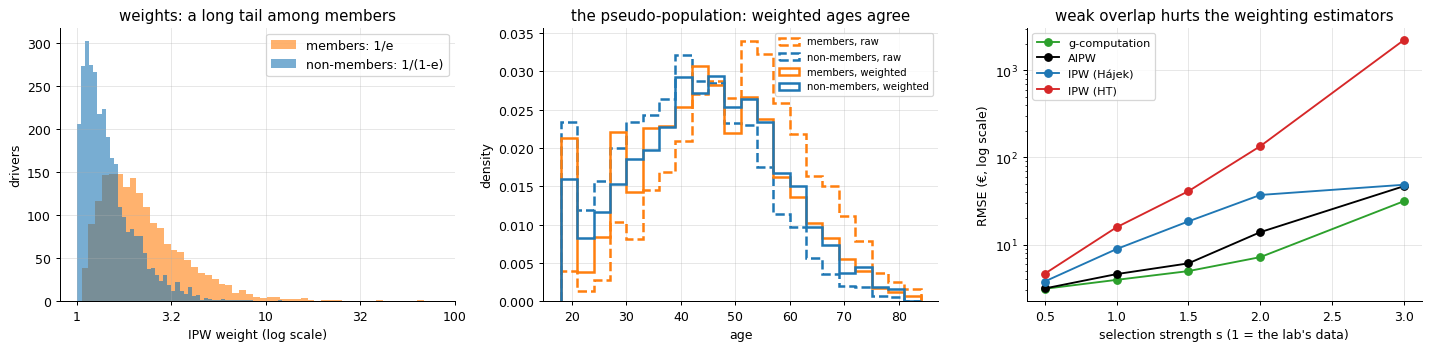

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lw = np.log10(np.concatenate([w1, w0]))
axes[0].hist(np.log10(w1), 50, alpha=0.6, color=C_TREAT, label="members: 1/e")
axes[0].hist(np.log10(w0), 50, alpha=0.6, color=C_CTRL, label="non-members: 1/(1-e)")
axes[0].set_xticks([0, 0.5, 1, 1.5, 2], ["1", "3.2", "10", "32", "100"]); axes[0].set_xlabel("IPW weight (log scale)")
axes[0].set_ylabel("drivers"); axes[0].legend(); axes[0].set_title("weights: a long tail among members")
b = np.arange(18, 86, 3)
for (lab, msk, w, c, ls) in [("members, raw", t_obs == 1, None, C_TREAT, "--"), ("non-members, raw", t_obs == 0, None, C_CTRL, "--"),
                             ("members, weighted", t_obs == 1, 1 / e_hat, C_TREAT, "-"), ("non-members, weighted", t_obs == 0, 1 / (1 - e_hat), C_CTRL, "-")]:
    axes[1].hist(df.age[msk], b, weights=None if w is None else w[msk], density=True, histtype="step", lw=2, color=c, ls=ls, label=lab)
axes[1].set_xlabel("age"); axes[1].set_ylabel("density"); axes[1].legend(fontsize=8)
axes[1].set_title("the pseudo-population: weighted ages agree")
for k, c in zip(["g-computation", "AIPW", "IPW (Hájek)", "IPW (HT)"], ["tab:green", "k", "tab:blue", "tab:red"]):
    axes[2].plot(strengths, rmse[k], "o-", color=c, label=k)
axes[2].set_yscale("log"); axes[2].set_xlabel("selection strength s (1 = the lab's data)"); axes[2].set_ylabel("RMSE (€, log scale)")
axes[2].legend(fontsize=9); axes[2].set_title("weak overlap hurts the weighting estimators")
plt.tight_layout(); plt.show()

**What just happened?** On our data the Hájek and the Horvitz–Thompson estimates coincide at −49.1 € (true −51.9), because the weights of each arm happen to sum to 4,999, almost exactly $n$; the stress test below shows that this is luck, not a rule. The largest member weight is 68.7 (a member with $\hat e = 0.015$, who stands for 69 drivers like him), the 1% largest member weights carry 7.7% of the members' total weight, and the 1,847 members are worth only 909 equally weighted ones (ESS). Clipping $\hat e$ to $[0.01, 0.99]$ changes nothing here; clipping to $[0.05, 0.95]$ raises the ESS to 1,128 but moves the estimate to −55.1 €, because the weights no longer rebuild the right population.

AIPW gives −51.0 € with an influence-function standard error of 4.2 €. The double-robustness table behaves as the algebra says: with the right outcome model the wrong propensity does not matter (−51.1 €), with the right propensity the wrong outcome model does not matter (−49.2 €), and with both wrong AIPW collapses exactly to the naive difference (−120.9 €).

The stress test shows the price of weak overlap. At the lab's selection strength ($s = 1$) the RMSE of Horvitz–Thompson is 15.8 €, Hájek 8.9 €, AIPW 4.6 € and g-computation 3.9 €, with an ESS of 54% of $n$. At $s = 3$ the median largest weight is 352 and the ESS 8% of $n$: Horvitz–Thompson's RMSE explodes to 2,230 €, and even Hájek (48.6 €), AIPW (46.9 €) and g-computation (31.5 €) degrade. The outcome-model-based estimators suffer least because they extrapolate smoothly where there are no comparable units; that is also their danger, since the extrapolation is invisible. Clipping or trimming the propensity buys variance at the price of a different estimand (the effect on the overlap population), and the first remedy is always to look at the overlap plot.

## 7. Uncertainty: bootstrap confidence intervals

A causal estimate without an interval is not a result. The nonparametric **bootstrap** gives one for every estimator with the same recipe:

1. draw $n$ rows with replacement;
2. redo **everything** on the resample: propensity model, outcome models, matching, weights (the uncertainty of the nuisance models is part of the uncertainty of the estimate);
3. repeat $B$ times; the standard deviation of the $B$ estimates is the standard error, and their 2.5% and 97.5% quantiles a 95% **percentile interval**.

Caveat: for nearest-neighbour matching with a fixed number of matches the bootstrap is known to be inconsistent (Abadie and Imbens, 2008); it is still a reasonable rough guide here, but use their analytic variance in serious work.

In [20]:
def all_estimates(X, t, y):
    e = fit_propensity(X, t); mu1, mu0 = fit_outcome_models(X, t, y)
    return [y[t == 1].mean() - y[t == 0].mean(), np.mean(mu1 - mu0), match_ate(e, t, y)[0], ipw(e, t, y),
            aipw(e, t, y, mu1, mu0)[0]]

EST_NAMES = ["naive", "regression adjustment", "PS matching", "IPW (Hájek)", "AIPW"]
point = all_estimates(X_all, t_obs, y_obs)
B = 500
rng_b = np.random.default_rng(5)
t0 = time.time()
boot = np.array([all_estimates(X_all[idx], t_obs[idx], y_obs[idx]) for idx in (rng_b.integers(0, N, N) for _ in range(B))])
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
res = pd.DataFrame({"estimate": point, "boot SE": boot.std(0, ddof=1), "2.5%": lo, "97.5%": hi}, index=EST_NAMES)
res["covers true ATE"] = (res["2.5%"] <= ATE_TRUE) & (ATE_TRUE <= res["97.5%"])
print(f"{B} bootstrap resamples in {time.time() - t0:.1f} s;  true ATE = {ATE_TRUE:.1f} €")
print(res.round(1).to_string())
print(f"AIPW: bootstrap SE {res.loc['AIPW', 'boot SE']:.2f} vs influence-function SE {se_aipw:.2f}")
assert not res.loc["naive", "covers true ATE"]
for k in EST_NAMES[1:]:
    assert abs(res.loc[k, "estimate"] - ATE_TRUE) < 3 * res.loc[k, "boot SE"]

500 bootstrap resamples in 3.6 s;  true ATE = -51.9 €
                       estimate  boot SE   2.5%  97.5%  covers true ATE
naive                    -120.9      4.6 -130.0 -111.2            False
regression adjustment     -51.1      4.1  -59.6  -43.2             True
PS matching               -47.8      5.5  -60.4  -39.2             True
IPW (Hájek)               -49.1      6.9  -62.9  -34.2             True
AIPW                      -51.0      4.3  -59.3  -42.5             True
AIPW: bootstrap SE 4.31 vs influence-function SE 4.23


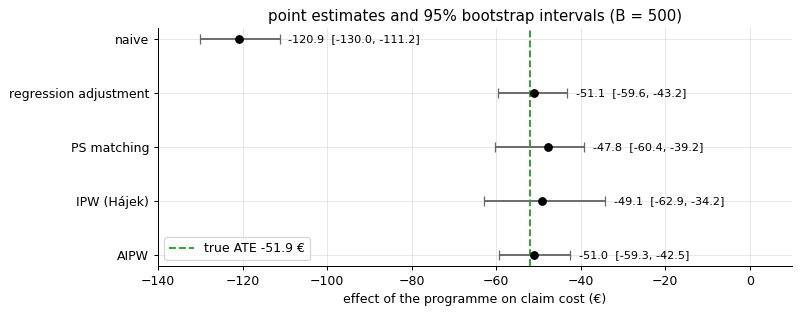

In [21]:
fig, ax = plt.subplots(figsize=(9, 3.6))
yy = np.arange(len(EST_NAMES))[::-1]
ax.errorbar(res["estimate"], yy, xerr=[res["estimate"] - res["2.5%"], res["97.5%"] - res["estimate"]], fmt="o",
            color="k", ecolor="0.4", capsize=4)
for k, (v, y_) in enumerate(zip(res["estimate"], yy)):
    ax.text(res["97.5%"].iloc[k] + 2, y_, f"{v:.1f}  [{res['2.5%'].iloc[k]:.1f}, {res['97.5%'].iloc[k]:.1f}]", va="center", fontsize=9)
ax.axvline(ATE_TRUE, color="tab:green", ls="--", label=f"true ATE {ATE_TRUE:.1f} €")
ax.set_yticks(yy, EST_NAMES); ax.set_xlim(-140, 10); ax.set_xlabel("effect of the programme on claim cost (€)")
ax.set_title(f"point estimates and 95% bootstrap intervals (B = {B})"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**What just happened?** The naive interval, [−130.0, −111.2] €, is far from the truth and excludes it: a precise answer to the wrong question. The four adjusted intervals all contain the true −51.9 €. Their standard errors rank them: regression adjustment (4.1 €) and AIPW (4.3 €) are the most precise, matching is wider (5.5 €) because each unit is compared with a single neighbour, and IPW is the widest (6.9 €) because of the long tail of weights. For AIPW the bootstrap SE and the influence-function SE agree (4.31 against 4.23). The 500 resamples, with every model refitted each time, took a few seconds.

In a report: "the telematics programme reduces the expected annual claim cost by about 51 € per driver (95% CI 43 to 59 €), under the assumption that age, mileage, past claims and urban/rural capture the reasons for joining". The last clause is not decoration; section 8 shows what happens when it fails.

## 8. Refutation tests and unobserved confounding

Ignorability cannot be tested, but some consequences of our analysis can. Libraries such as **DoWhy** automate these **refuters**; here they are in a few lines:

- **Placebo treatment**: replace $T$ by a random permutation of itself. The fake treatment has no effect by construction, so the estimate should be about zero. If it is not, the pipeline finds effects where there are none (leakage, a bug, overfitting).
- **Random common cause**: add a random covariate. A sound estimator should not move.
- **Unobserved confounding**: we cannot add the confounder we do not have, but we can see how much the estimate moves when we *remove* each confounder we do have. If dropping one known covariate shifts the answer by 30 €, an unknown one of similar strength could too.

In [22]:
rng_p = np.random.default_rng(6)
def aipw_estimate(X, t, y):
    e = fit_propensity(X, t); mu1, mu0 = fit_outcome_models(X, t, y)
    return aipw(e, t, y, mu1, mu0)[0]

placebo = np.array([aipw_estimate(X_all, rng_p.permutation(t_obs), y_obs) for _ in range(200)])
p_value = np.mean(np.abs(placebo) >= abs(est_aipw))
print(f"placebo treatment (200 permutations): mean {placebo.mean():.2f} €, sd {placebo.std():.2f}, "
      f"max |estimate| {np.abs(placebo).max():.1f};  real AIPW {est_aipw:.1f}  ->  p = {p_value:.3f}")
X_rcc = np.column_stack([X_all, rng_p.normal(size=N)])
est_rcc = aipw_estimate(X_rcc, t_obs, y_obs)
print(f"random common cause added: AIPW {est_rcc:.2f} € (was {est_aipw:.2f}, change {est_rcc - est_aipw:+.2f})")
drop = {}
for k, c in enumerate(COVARIATES):
    keep = [j for j in range(len(COVARIATES)) if j != k]
    drop[c] = aipw_estimate(X_all[:, keep], t_obs, y_obs)
    print(f"   without {c:6s} (pretend it is unobserved): AIPW {drop[c]:7.1f} €   bias {drop[c] - ATE_TRUE:+6.1f}")
assert abs(placebo.mean()) < 2 and abs(est_rcc - est_aipw) < 2 and drop["claims"] - ATE_TRUE < -20

placebo treatment (200 permutations): mean -0.19 €, sd 3.38, max |estimate| 9.4;  real AIPW -51.0  ->  p = 0.000
random common cause added: AIPW -50.90 € (was -50.98, change +0.08)
   without age    (pretend it is unobserved): AIPW   -65.3 €   bias  -13.4
   without km     (pretend it is unobserved): AIPW   -75.9 €   bias  -24.0
   without claims (pretend it is unobserved): AIPW   -80.0 €   bias  -28.1
   without urban  (pretend it is unobserved): AIPW   -53.4 €   bias   -1.5


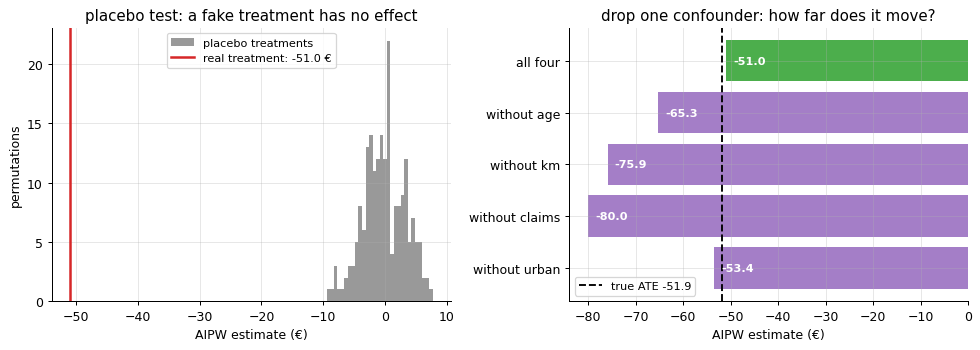

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(placebo, 30, color="0.6", label="placebo treatments")
axes[0].axvline(est_aipw, color="tab:red", lw=2, label=f"real treatment: {est_aipw:.1f} €")
axes[0].set_xlabel("AIPW estimate (€)"); axes[0].set_ylabel("permutations"); axes[0].legend(fontsize=9)
axes[0].set_title("placebo test: a fake treatment has no effect")
names = ["all four"] + [f"without {c}" for c in COVARIATES]
vals = [est_aipw] + [drop[c] for c in COVARIATES]
axes[1].barh(range(5), vals, color=["tab:green"] + ["tab:purple"] * 4, alpha=0.85)
for k, v in enumerate(vals):
    axes[1].text(v + 1.5, k, f"{v:.1f}", va="center", ha="left", fontsize=9, color="white", fontweight="bold")
axes[1].axvline(ATE_TRUE, color="k", ls="--", label=f"true ATE {ATE_TRUE:.1f}")
axes[1].set_yticks(range(5), names); axes[1].invert_yaxis(); axes[1].set_xlabel("AIPW estimate (€)")
axes[1].legend(loc="lower left", fontsize=9); axes[1].set_title("drop one confounder: how far does it move?")
plt.tight_layout(); plt.show()

**What just happened?** Under 200 placebo treatments the AIPW estimates scatter around −0.19 € with a standard deviation of 3.4 €; the largest is 9.4 € in absolute value, far from the real −51.0 € (none of the 200 placebos is as extreme, $p < 0.005$). Adding a column of noise moves the estimate by +0.08 €. Both refuters pass.

The drop-one analysis is the sobering part. Hiding **past claims** turns −51.0 € into −80.0 €, a bias of −28.1 € that no diagnostic flags: the overlap plot, the balance table (on the remaining covariates) and the refuters all look fine. Hiding **km** gives −75.9 €, hiding **age** −65.3 €; only **urban**, a weak confounder, barely matters (−53.4 €). Refuters can expose a broken pipeline, never a missing confounder. Formal **sensitivity analyses** ask how strong an unobserved confounder would have to be to explain the effect away: Rosenbaum's $\Gamma$ for matched designs, the **E-value** (VanderWeele and Ding, 2017), or omitted-variable-bias bounds benchmarked, as here, against the observed covariates (Cinelli and Hazlett, 2020).

When ignorability is not credible, look for a different **design**: a **difference-in-differences** (compare the change over time of a group that got the programme with one that did not; assumes parallel trends) or an **instrumental variable** (something that shifts the treatment but affects the outcome only through it, such as a randomised encouragement to join). The slides cover both.

## 9. A randomised retention campaign: heterogeneous effects

Now the insurer has done things properly. Before the renewal date, a **random half** of 40,000 customers got a retention call with a small discount; the other half got nothing. The outcome is whether the customer **stayed** ($Y = 1$) or left ($Y = 0$). Because the assignment is random, the average effect is a simple difference of retention rates. But the business question is different: **whom should we call next year?** The answer depends on the **conditional average treatment effect**, here called the **uplift**:

$$
\tau(x) = P(Y = 1 \mid \mathrm{do}(T = 1), X = x) - P(Y = 1 \mid \mathrm{do}(T = 0), X = x).
$$

Customers come in four types, defined by their two potential outcomes (Radcliffe and Surry):

| | stays if not called, $Y(0) = 1$ | leaves if not called, $Y(0) = 0$ |
|---|---|---|
| **stays if called**, $Y(1) = 1$ | **sure thing**: the call is wasted | **persuadable**: the call saves her |
| **leaves if called**, $Y(1) = 0$ | **sleeping dog**: the call *makes* her leave | **lost cause**: the call is wasted |

Only persuadables are worth a call; sleeping dogs are worth *not* calling. In the simulator the covariates are the premium increase at renewal (0 to 25%), the tenure (years), whether the last claim was badly handled, age, online purchase, and the number of policies. Price-sensitive customers who face a large increase are the persuadables; unhappy claimants are lost causes; long-tenure customers with a small increase are mostly sure things, but a call reminds some of them to compare prices: sleeping dogs. We simulate both potential outcomes for every customer from one uniform draw, so the four types are known exactly.

In [24]:
def simulate_retention(n, rng):
    '''Randomised retention campaign. Returns covariates, T, Y (1 = stayed) and the hidden truth.'''
    increase = rng.uniform(0, 25, n)                             # premium increase at renewal, %
    tenure = np.minimum(rng.exponential(7, n), 30)                # years with the insurer
    bad_claim = rng.binomial(1, 0.12, n)                          # last claim badly handled
    age = np.clip(rng.normal(48, 15, n), 18, 90)
    online = rng.binomial(1, 0.4, n)
    products = rng.choice([1, 2, 3], n, p=[0.55, 0.3, 0.15])
    p0 = sigmoid(-2.4 + 0.11 * (increase - 10) - 0.07 * (tenure - 6) + 2.3 * bad_claim + 0.4 * online
                 - 0.35 * (products - 1) - 0.01 * (age - 48))    # P(leave | no call)
    s_inc = sigmoid((increase - 12) / 2)
    drop = 0.22 * s_inc * (1 - bad_claim) * (0.7 + 0.6 * online) - 0.15 * sigmoid((tenure - 8) / 1.5) * (1 - s_inc)
    p1 = np.clip(p0 - drop, 0.005, 0.995)                         # P(leave | call)
    u = rng.uniform(size=n)                                       # one draw couples the two potential outcomes
    leave0, leave1 = (u < p0).astype(int), (u < p1).astype(int)
    t = rng.binomial(1, 0.5, n)                                   # the A/B test
    X = pd.DataFrame({"increase": increase, "tenure": tenure, "bad_claim": bad_claim, "age": age,
                      "online": online, "products": products})
    return X, t, 1 - np.where(t == 1, leave1, leave0), {"uplift": p0 - p1, "p_leave0": p0, "Y0": 1 - leave0, "Y1": 1 - leave1}

Xr, tr_, yr, truth = simulate_retention(40_000, np.random.default_rng(5))
Xr_np = Xr.to_numpy(float)
types = np.select([(truth["Y0"] == 1) & (truth["Y1"] == 1), (truth["Y0"] == 0) & (truth["Y1"] == 1),
                   (truth["Y0"] == 0) & (truth["Y1"] == 0)], ["sure thing", "persuadable", "lost cause"], "sleeping dog")
rate1, rate0 = yr[tr_ == 1].mean(), yr[tr_ == 0].mean()
se = np.sqrt(rate1 * (1 - rate1) / (tr_ == 1).sum() + rate0 * (1 - rate0) / (tr_ == 0).sum())
print(f"retention: called {rate1:.2%}, not called {rate0:.2%}  ->  ATE = {rate1 - rate0:+.2%} "
      f"(95% CI {rate1 - rate0 - 1.96 * se:+.2%} to {rate1 - rate0 + 1.96 * se:+.2%});  true ATE {truth['uplift'].mean():+.2%}")
counts = pd.Series(types).value_counts().reindex(["sure thing", "persuadable", "lost cause", "sleeping dog"])
print("\nthe four types (known only because we simulate):"); print((counts / len(types)).map("{:.2%}".format).to_string())
share = counts / len(types)
print(f"\nshare of persuadables - share of sleeping dogs = {share['persuadable'] - share['sleeping dog']:.4f}"
      f" = sample ATE {np.mean(truth['Y1'] - truth['Y0']):.4f}")
assert np.isclose(share["persuadable"] - share["sleeping dog"], np.mean(truth["Y1"] - truth["Y0"]))
print(f"customers with a negative true uplift: {(truth['uplift'] < 0).mean():.1%} (below -0.05: {(truth['uplift'] < -0.05).mean():.1%})")
print(f"correlation between the churn risk without a call and the true uplift: {np.corrcoef(truth['p_leave0'], truth['uplift'])[0, 1]:.3f}")

retention: called 87.96%, not called 82.72%  ->  ATE = +5.23% (95% CI +4.54% to +5.93%);  true ATE +5.63%

the four types (known only because we simulate):
sure thing      80.82%
persuadable      7.36%
lost cause      10.05%
sleeping dog     1.77%

share of persuadables - share of sleeping dogs = 0.0559 = sample ATE 0.0559
customers with a negative true uplift: 36.5% (below -0.05: 14.1%)
correlation between the churn risk without a call and the true uplift: 0.287


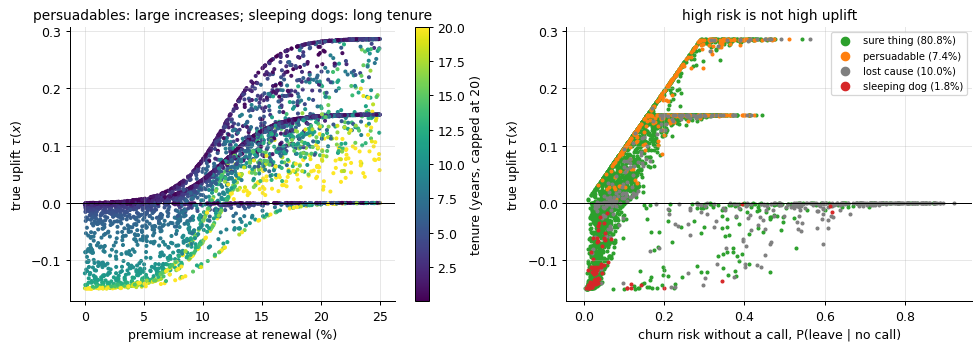

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sub = np.random.default_rng(0).choice(len(yr), 4000, replace=False)
sc = axes[0].scatter(Xr.increase.iloc[sub], truth["uplift"][sub], c=np.minimum(Xr.tenure.iloc[sub], 20), cmap="viridis", s=5)
plt.colorbar(sc, ax=axes[0], label="tenure (years, capped at 20)")
axes[0].axhline(0, color="k", lw=0.8); axes[0].set_xlabel("premium increase at renewal (%)"); axes[0].set_ylabel(r"true uplift $\tau(x)$")
axes[0].set_title("persuadables: large increases; sleeping dogs: long tenure", fontsize=11)
colors = {"sure thing": "tab:green", "persuadable": "tab:orange", "lost cause": "tab:gray", "sleeping dog": "tab:red"}
for ty in colors:
    m = types[sub] == ty
    axes[1].scatter(truth["p_leave0"][sub][m], truth["uplift"][sub][m], s=5, color=colors[ty], label=f"{ty} ({share[ty]:.1%})")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_xlabel("churn risk without a call, P(leave | no call)")
axes[1].set_ylabel(r"true uplift $\tau(x)$"); axes[1].legend(fontsize=8, markerscale=3)
axes[1].set_title("high risk is not high uplift", fontsize=11)
plt.tight_layout(); plt.show()

**What just happened?** The campaign raises retention from 82.7% to 88.0%: an average effect of +5.2 points (true +5.6), precisely estimated because the assignment was random (95% CI +4.5 to +5.9). Behind the average: 80.8% of customers are sure things, 7.4% persuadables, 10.1% lost causes and 1.8% sleeping dogs. The individual effects average exactly to the share of persuadables minus the share of sleeping dogs, 5.59 points (each persuadable adds a stay, each sleeping dog removes one). 36.5% of the customers have a negative expected uplift, and for 14.1% it is below −5 points: for them a call does harm on average.

The right panel holds the key message of uplift modelling. The customers with the highest churn risk (right side) are mostly **lost causes**: unhappy claimants who leave whatever we do. The correlation between churn risk and uplift is only 0.29. A classic churn model ranks customers by risk, so it would spend the campaign budget on the wrong people. We need a model of $\tau(x)$, not of $P(Y \mid x)$.

## 10. Meta-learners S, T and X from scratch

We never observe $\tau_i$, so we cannot regress it on $x$ directly. **Meta-learners** build a CATE estimator out of ordinary supervised models ("base learners", here scikit-learn's histogram gradient boosting):

- **S-learner** (single model): fit $\hat\mu(x, t)$ with the treatment as one more feature; $\hat\tau(x) = \hat\mu(x, 1) - \hat\mu(x, 0)$. Simple, but a regularised model may barely use $t$ and shrink the effect towards zero.
- **T-learner** (two models): fit $\hat\mu_1$ on the treated and $\hat\mu_0$ on the controls; $\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$. Each model is fitted on half the data, and the difference of two noisy functions is noisier still.
- **X-learner** (Künzel et al., 2019): start from the T-learner, then **impute** individual effects: $\tilde D_i^1 = Y_i - \hat\mu_0(x_i)$ for the treated and $\tilde D_i^0 = \hat\mu_1(x_i) - Y_i$ for the controls. Regress each on $x$ to get $\hat\tau_1(x)$ and $\hat\tau_0(x)$, and combine them, $\hat\tau(x) = g(x)\,\hat\tau_0(x) + (1 - g(x))\,\hat\tau_1(x)$, with $g = \hat e(x)$ ($0.5$ here, a randomised trial). It shines when one arm is much smaller than the other.
- **R-learner** and **DR-learner** (not built here): regress a Neyman-orthogonal pseudo-outcome (residual-on-residual, or the AIPW terms $\psi_i$ of section 6) on $x$, with cross-fitting. They are the workhorses of EconML.

Half of the customers train the learners; the other half is a test set where we compare the estimates with the true uplift (which only a simulation can give) and, in section 11, evaluate them the way one must in real life, without the truth.

In [26]:
HGB = dict(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=50, random_state=0)
train = np.arange(len(yr)) < 20_000; test = ~train
Xtr, ttr, ytr, Xte = Xr_np[train], tr_[train], yr[train], Xr_np[test]

def s_learner(X, t, y, X_new):
    m = HistGradientBoostingClassifier(**HGB).fit(np.column_stack([X, t]), y)
    p = lambda tt: m.predict_proba(np.column_stack([X_new, np.full(len(X_new), tt)]))[:, 1]
    return p(1) - p(0)

def t_learner(X, t, y, X_new, return_models=False):
    m1 = HistGradientBoostingClassifier(**HGB).fit(X[t == 1], y[t == 1])
    m0 = HistGradientBoostingClassifier(**HGB).fit(X[t == 0], y[t == 0])
    tau = m1.predict_proba(X_new)[:, 1] - m0.predict_proba(X_new)[:, 1]
    return (tau, m1, m0) if return_models else tau

def x_learner(X, t, y, X_new):
    _, m1, m0 = t_learner(X, t, y, X_new, return_models=True)
    d1 = y[t == 1] - m0.predict_proba(X[t == 1])[:, 1]          # imputed effects of the treated
    d0 = m1.predict_proba(X[t == 0])[:, 1] - y[t == 0]          # imputed effects of the controls
    tau1 = HistGradientBoostingRegressor(**HGB).fit(X[t == 1], d1).predict(X_new)
    tau0 = HistGradientBoostingRegressor(**HGB).fit(X[t == 0], d0).predict(X_new)
    g = t.mean()                                                 # propensity: constant in an A/B test
    return g * tau0 + (1 - g) * tau1

t0 = time.time()
cate = {"S-learner": s_learner(Xtr, ttr, ytr, Xte), "T-learner": t_learner(Xtr, ttr, ytr, Xte),
        "X-learner": x_learner(Xtr, ttr, ytr, Xte)}
risk_model = HistGradientBoostingClassifier(**HGB).fit(Xtr[ttr == 0], 1 - ytr[ttr == 0])   # classic churn model
churn_risk = risk_model.predict_proba(Xte)[:, 1]
print(f"fitted 1 + 2 + 4 + 1 boosting models in {time.time() - t0:.1f} s")
u_te = truth["uplift"][test]
print(f"{'':10s} {'RMSE':>7s} {'corr':>7s} {'mean (est. ATE)':>16s}")
for k, v in cate.items():
    print(f"{k:10s} {np.sqrt(np.mean((v - u_te) ** 2)):7.4f} {np.corrcoef(v, u_te)[0, 1]:7.3f} {v.mean():16.4f}")
print(f"{'truth':10s} {'':7s} {'':7s} {u_te.mean():16.4f}")
print(f"churn risk vs true uplift: corr {np.corrcoef(churn_risk, u_te)[0, 1]:.3f}")
assert all(np.corrcoef(v, u_te)[0, 1] > 0.75 for v in cate.values())

fitted 1 + 2 + 4 + 1 boosting models in 1.3 s
              RMSE    corr  mean (est. ATE)
S-learner   0.0397   0.930           0.0561
T-learner   0.0645   0.859           0.0555
X-learner   0.0387   0.937           0.0557
truth                                0.0567
churn risk vs true uplift: corr 0.299


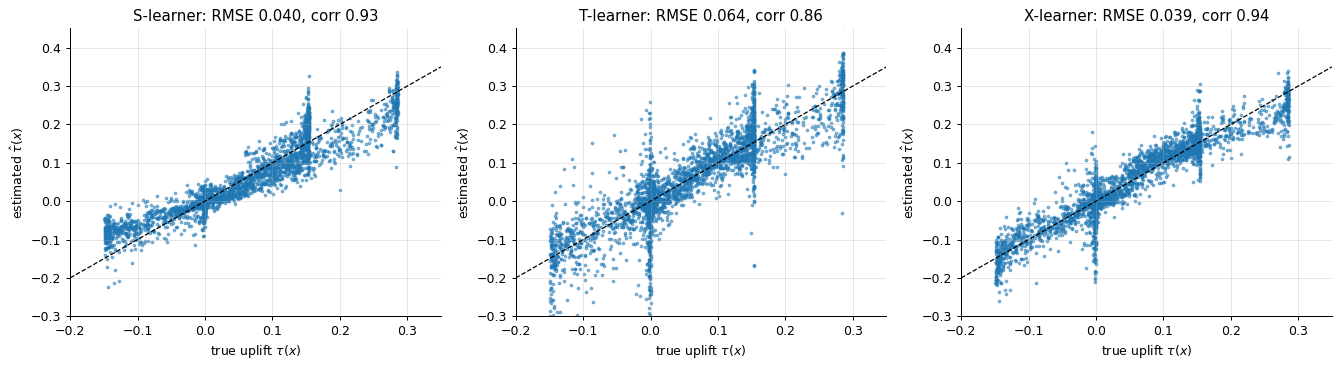

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sub = np.random.default_rng(1).choice(test.sum(), 3000, replace=False)
for ax, (k, v) in zip(axes, cate.items()):
    ax.scatter(u_te[sub], v[sub], s=4, alpha=0.5, color="tab:blue")
    ax.plot([-0.2, 0.35], [-0.2, 0.35], "k--", lw=1)
    ax.set_xlim(-0.2, 0.35); ax.set_ylim(-0.3, 0.45)
    ax.set_xlabel(r"true uplift $\tau(x)$"); ax.set_ylabel(r"estimated $\hat\tau(x)$")
    ax.set_title(f"{k}: RMSE {np.sqrt(np.mean((v - u_te) ** 2)):.3f}, corr {np.corrcoef(v, u_te)[0, 1]:.2f}")
plt.tight_layout(); plt.show()

**What just happened?** All three learners recover the shape of the uplift, from 20,000 customers whose individual effects were never observed: correlations with the truth of 0.93 (S), 0.86 (T) and 0.94 (X). The T-learner is the noisiest (RMSE 0.064 against 0.040 and 0.039): each of its two models sees only half the training data and their errors do not cancel in the difference. The X-learner fixes this by smoothing the imputed effects with a second model; here the S-learner does about as well, because the effect is large and boosting picks up the treatment feature. With a weak effect, or very unequal arms, the S-learner's shrinkage towards zero becomes a real problem.

The mean of each estimate (0.056, 0.056, 0.056) is close to the true average uplift of the test customers (0.057). The classic churn model's scores correlate only 0.30 with the uplift.

## 11. Uplift and Qini curves; targeting the persuadables

In real life the true uplift is unknown, so we cannot compute an RMSE. But the test set is a **randomised** experiment, and that is enough to evaluate a *ranking*. Sort the test customers by predicted uplift, from highest to lowest. For the top $k$, let $n_t(k)$ and $n_c(k)$ be the numbers of treated and control customers, and $r_t(k)$, $r_c(k)$ the numbers who stayed. Then:

- the **Qini curve** (Radcliffe, 2007) counts the incremental responders among the treated of the top $k$, scaling the controls to the same size:
$$Q(k) = r_t(k) - r_c(k)\,\frac{n_t(k)}{n_c(k)};$$
- the **uplift curve** estimates the extra stays if we called all top-$k$ customers:
$$U(k) = \Big(\frac{r_t(k)}{n_t(k)} - \frac{r_c(k)}{n_c(k)}\Big)\,k .$$

Both end at the overall effect ($U(n) = n \cdot \widehat{\text{ATE}}$; $Q(n) \approx n_t \cdot \widehat{\text{ATE}}$). A random ranking gives the straight line from the origin to that end point. A good model rises steeply first (persuadables), flattens (sure things and lost causes) and falls at the end (sleeping dogs). The **Qini coefficient** is the area between the model's Qini curve and the random line, here with the horizontal axis as the *fraction* targeted, so it is measured in customers. It is often normalised by the area of the best possible curve, which on real data can only be estimated.

First a tiny example, the one on the slides: 12 customers already sorted by predicted uplift.

In [28]:
toy_t = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])     # called?  (sorted by predicted uplift)
toy_y = np.array([1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1])     # stayed?

def qini_curve(score, t, y):
    '''Q(k) for k = 0..n, customers sorted by decreasing score (stable sort keeps ties in order).'''
    o = np.argsort(-score, kind="stable"); t, y = t[o], y[o]
    nt, nc = np.cumsum(t), np.cumsum(1 - t); rt, rc = np.cumsum(y * t), np.cumsum(y * (1 - t))
    q = rt - np.where(nc > 0, rc * nt / np.maximum(nc, 1), 0.0)
    return np.concatenate([[0.0], q])

def uplift_curve(score, t, y):
    o = np.argsort(-score, kind="stable"); t, y = t[o], y[o]
    nt, nc = np.cumsum(t), np.cumsum(1 - t); rt, rc = np.cumsum(y * t), np.cumsum(y * (1 - t))
    k = np.arange(1, len(t) + 1)
    u = (np.where(nt > 0, rt / np.maximum(nt, 1), 0) - np.where(nc > 0, rc / np.maximum(nc, 1), 0)) * k
    return np.concatenate([[0.0], u])

def qini_coefficient(q):
    '''Area between the Qini curve and the random line, x = fraction targeted (0..1).'''
    x = np.linspace(0, 1, len(q))
    return (getattr(np, "trapezoid", None) or np.trapz)(q, x) - q[-1] / 2

toy_q = qini_curve(-np.arange(12.0), toy_t, toy_y)
toy = pd.DataFrame({"k": np.arange(1, 13), "called": toy_t, "stayed": toy_y, "n_t": np.cumsum(toy_t),
                    "n_c": np.cumsum(1 - toy_t), "r_t": np.cumsum(toy_t * toy_y), "r_c": np.cumsum((1 - toy_t) * toy_y),
                    "Q(k)": toy_q[1:]})
print(toy.round(2).to_string(index=False))
print(f"random line ends at Q(12) = {toy_q[-1]:.0f};  Qini coefficient = {qini_coefficient(toy_q):.3f}")
assert np.isclose(toy_q[5], 3 - 0 * 3 / 2) and np.isclose(toy_q[6], 3 - 1 * 3 / 3) and np.isclose(toy_q[-1], 4 - 4)

 k  called  stayed  n_t  n_c  r_t  r_c  Q(k)
 1       1       1    1    0    1    0  1.00
 2       0       0    1    1    1    0  1.00
 3       1       1    2    1    2    0  2.00
 4       0       0    2    2    2    0  2.00
 5       1       1    3    2    3    0  3.00
 6       0       1    3    3    3    1  2.00
 7       1       1    4    3    4    1  2.67
 8       0       1    4    4    4    2  2.00
 9       1       0    5    4    4    2  1.50
10       0       1    5    5    4    3  1.00
11       1       0    6    5    4    3  0.40
12       0       1    6    6    4    4  0.00
random line ends at Q(12) = 0;  Qini coefficient = 1.547


In the toy list the first three treated customers all stayed and the first two controls left, so $Q$ climbs to $3 - 0 = 3$ at $k = 5$. Further down, the controls stay and the treated leave: the bottom of the list looks like sleeping dogs, and $Q$ ends at $4 - 4 \cdot 6/6 = 0$. Calling all twelve gains nothing on average; calling the top five gains three customers. The Qini coefficient of this ranking is 1.55 (the area under $Q$ with $x = k/12$, minus the area under the random line, which is 0 here because $Q(12) = 0$).

Now the 20,000 test customers. Besides the three learners we rank by the classic **churn risk** score, at random, and by the **true uplift** (the oracle, available only in a simulation). Because we know the true uplift, we can also check the *empirical* uplift curve, computed from the observed outcomes, against the *expected* number of extra stays, $\sum_{i \le k} \tau(x_i)$.

In [29]:
t_te, y_te, types_te = tr_[test], yr[test], types[test]
n_te = test.sum()
scores = {"random": np.random.default_rng(7).random(n_te), "churn risk": churn_risk, **cate, "oracle (true uplift)": u_te}
curves, rows = {}, []
for k, s in scores.items():
    q, upl = qini_curve(s, t_te, y_te), uplift_curve(s, t_te, y_te)
    expected = np.concatenate([[0], np.cumsum(u_te[np.argsort(-s, kind="stable")])])
    curves[k] = (q, upl, expected)
    top = np.argsort(-s, kind="stable")[: n_te // 5]                     # budget: call 20% of the customers
    rows.append({"ranking": k, "Qini coef.": qini_coefficient(q), "extra stays @20% (estimated)": upl[n_te // 5],
                 "extra stays @20% (true)": u_te[top].sum(), "best fraction": np.argmax(expected) / n_te,
                 "persuadables @20%": np.mean(types_te[top] == "persuadable"),
                 "lost causes @20%": np.mean(types_te[top] == "lost cause"),
                 "sleeping dogs @20%": np.mean(types_te[top] == "sleeping dog")})
qtab = pd.DataFrame(rows).set_index("ranking")
qtab["Qini / oracle"] = qtab["Qini coef."] / qtab.loc["oracle (true uplift)", "Qini coef."]
print(qtab.round(3).to_string())
print(f"\ncall everybody: {u_te.sum():.0f} expected extra stays;  "
      f"call the top {qtab.loc['X-learner', 'best fraction']:.0%} by X-learner: {curves['X-learner'][2].max():.0f}")
V, c = 150, 5                                  # value of a retained customer, cost of a call (€)
for k in ["churn risk", "X-learner", "oracle (true uplift)"]:
    s = scores[k]
    call = s > c / V if k != "churn risk" else np.argsort(np.argsort(-s)) < np.sum(cate["X-learner"] > c / V)
    print(f"V = {V} €, c = {c} €: {k:22s} calls {call.mean():.1%}, expected net value {np.sum(V * u_te[call] - c):,.0f} €"
          + ("  (same number of calls, chosen by risk)" if k == "churn risk" else f"  (rule: call if score > c/V = {c / V:.3f})"))
print(f"   calling everybody: {np.sum(V * u_te - c):,.0f} €")
assert qtab.loc["X-learner", "extra stays @20% (true)"] > 1.5 * qtab.loc["churn risk", "extra stays @20% (true)"]
assert qtab.loc["X-learner", "Qini coef."] > qtab.loc["churn risk", "Qini coef."] > qtab.loc["random", "Qini coef."]

                      Qini coef.  extra stays @20% (estimated)  extra stays @20% (true)  best fraction  persuadables @20%  lost causes @20%  sleeping dogs @20%  Qini / oracle
ranking                                                                                                                                                                       
random                    -8.689                       204.575                  214.662          1.000              0.076             0.096               0.020         -0.027
churn risk               185.947                       397.501                  431.719          0.720              0.110             0.330               0.004          0.585
S-learner                310.588                       790.187                  789.670          0.659              0.190             0.067               0.000          0.977
T-learner                278.013                       706.701                  766.649          0.674              0.183    

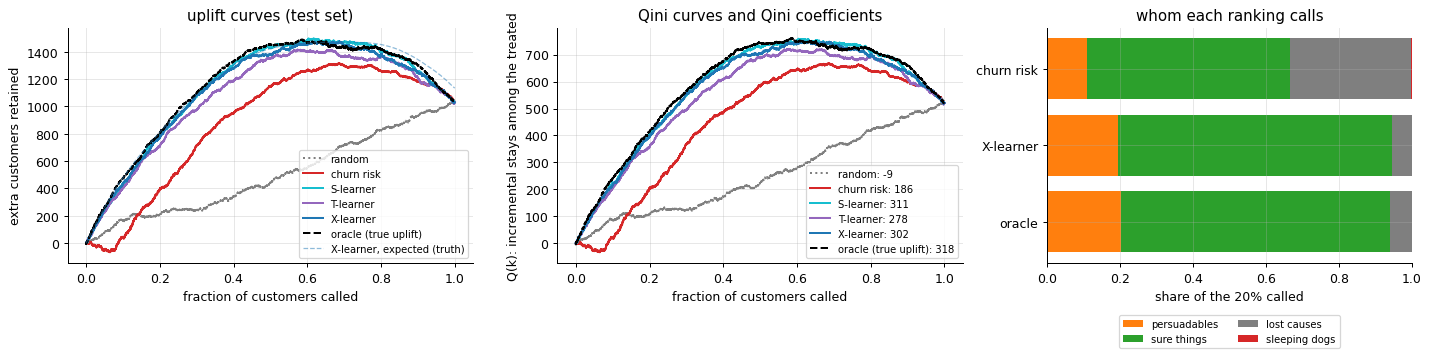

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1, 1, 0.9]})
x = np.linspace(0, 1, n_te + 1)
style = {"random": ("0.5", ":"), "churn risk": ("tab:red", "-"), "S-learner": ("tab:cyan", "-"), "T-learner": ("tab:purple", "-"),
         "X-learner": ("tab:blue", "-"), "oracle (true uplift)": ("k", "--")}
for k, (q, upl, expected) in curves.items():
    c, ls = style[k]
    axes[0].plot(x, upl, color=c, ls=ls, lw=1.6, label=k)
    axes[1].plot(x, q, color=c, ls=ls, lw=1.6, label=f"{k}: {qtab.loc[k, 'Qini coef.']:.0f}")
axes[0].plot(x, curves["X-learner"][2], color="tab:blue", lw=1, alpha=0.5, ls="--", label="X-learner, expected (truth)")
axes[0].set_xlabel("fraction of customers called"); axes[0].set_ylabel("extra customers retained")
axes[0].set_title("uplift curves (test set)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("fraction of customers called"); axes[1].set_ylabel("Q(k): incremental stays among the treated")
axes[1].set_title("Qini curves and Qini coefficients"); axes[1].legend(fontsize=8)
comp = qtab.loc[["churn risk", "X-learner", "oracle (true uplift)"], ["persuadables @20%", "lost causes @20%", "sleeping dogs @20%"]]
comp["sure things @20%"] = 1 - comp.sum(1)
left = np.zeros(3)
for col, c in zip(["persuadables @20%", "sure things @20%", "lost causes @20%", "sleeping dogs @20%"],
                  ["tab:orange", "tab:green", "tab:gray", "tab:red"]):
    axes[2].barh(range(3), comp[col], left=left, color=c, label=col.replace(" @20%", ""))
    left += comp[col].to_numpy()
axes[2].set_yticks(range(3), ["churn risk", "X-learner", "oracle"]); axes[2].invert_yaxis()
axes[2].set_xlabel("share of the 20% called"); axes[2].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
axes[2].set_title("whom each ranking calls")
plt.tight_layout(); plt.show()

**What just happened?** With a budget of 20% of the customers (4,000 calls), ranking by the X-learner brings 813 expected extra stays; ranking by churn risk only 432, and calling at random 215. The oracle, which knows the true uplift, gets 834: the learners capture almost all of what is achievable. The composition explains it: the top 20% by churn risk is 33% lost causes and 11% persuadables, the top 20% by X-learner 19% persuadables and 5% lost causes. A churn model answers "who will leave?", and the honest answer is "the unhappy claimants, whatever we do".

The empirical uplift curve, computed only from observed outcomes of the randomised test set, follows the expected curve that uses the hidden truth (at 20%: 776 estimated against 813 expected for the X-learner): this is why a randomised hold-out is the standard way to evaluate uplift models. The Qini coefficients tell the same story: S-learner 311, X-learner 302, T-learner 278 (S and X are within noise of each other and close to the oracle's 318), churn risk 186, random −9.

All curves peak before the end: calling everybody yields 1,134 expected extra stays, calling the best 69% (by the X-learner's ranking) yields 1,471. The last customers in the ranking are sleeping dogs and sure things: each call costs money and some of them lose a customer. With a cost $c$ per call and a value $V$ per retained customer, the optimal rule is simply: call customer $i$ if and only if $V\,\hat\tau(x_i) > c$. With $V = 150$ € and $c = 5$ €, the X-learner calls 53.2% of the customers and creates an expected net value of 162,985 € on the test set (the oracle: 167,964 €). The same number of calls chosen by churn risk creates 134,621 €, and calling everybody only 70,079 €.

In [31]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on cpu")

whole notebook: 0.2 min on cpu


## 12. Summary

- **Prediction vs intervention**: $P(Y \mid T = t)$ is not $P(Y \mid \mathrm{do}(T = t))$ when something drives both $T$ and $Y$. Kidney stones: the raw data favour B by 4.6 points, adjusting for stone size favours A by 5.4 (83.3% against 77.9%). The adjustment formula $\sum_z P(Y \mid t, z)P(z)$ and inverse probability weighting give identical numbers.
- **Potential outcomes**: $\tau_i = Y_i(1) - Y_i(0)$ is never observed. Naive difference = ATT + selection bias: $-120.9 = -37.7 - 83.1$ € for the telematics programme, whose true ATE is $-51.9$ €. Randomisation makes the selection bias zero: 500 coin-flip replays average $-52.1$ €, 500 self-selected ones $-123.8$ €.
- **Assumptions** without randomisation: SUTVA and consistency, **ignorability** $(Y(1), Y(0)) \perp T \mid X$ (untestable), **positivity** $0 < e(x) < 1$ (testable). Then $\mathbb{E}[Y(t) \mid X] = \mu_t(X)$.
- **DAGs**: conditioning blocks a chain or a fork and opens a collider (partial correlation $-0.52$ in the simulated collider, $-0.64$ between talent and looks among actors). Backdoor criterion: block every backdoor path, adjust for no descendant of $T$. Bad controls: a mediator gives the direct effect only ($-20.0$ €), selecting on a collider biases ($-38.8$ € among renewers).
- **Estimators under unconfoundedness**: regression adjustment (g-computation) $\frac1n\sum(\hat\mu_1 - \hat\mu_0)$; propensity matching; IPW $\frac1n\sum\big[\frac{TY}{\hat e} - \frac{(1-T)Y}{1-\hat e}\big]$, unbiased because $\mathbb{E}[TY/e(X)] = \mathbb{E}[Y(1)]$; AIPW $\frac1n\sum\big[\hat\mu_1 - \hat\mu_0 + \frac{T(Y - \hat\mu_1)}{\hat e} - \frac{(1-T)(Y - \hat\mu_0)}{1 - \hat e}\big]$, doubly robust. Lab: $-51.1$, $-47.8$, $-49.1$ and $-51.0$ € (AIPW 95% bootstrap CI $[-59.3, -42.5]$), against a naive $-120.9$ € $[-130.0, -111.2]$.
- **Overlap and weights**: check the overlap plot and the balance (|SMD| < 0.1); Hájek / stabilised weights; effective sample size $(\sum w)^2/\sum w^2$ (909 of 1,847 members). With weak overlap ($s = 3$) the Horvitz–Thompson RMSE explodes to 2,230 €.
- **Refutation and sensitivity**: placebo treatments average $-0.19$ €, a random common cause moves the estimate by $+0.08$ €, but hiding a real confounder (past claims) shifts it to $-80.0$ € with no warning. Other designs when ignorability fails: difference-in-differences (parallel trends), instrumental variables (exclusion restriction).
- **Uplift**: $\tau(x)$ for a randomised retention campaign. Four types: sure things 80.8%, persuadables 7.4%, lost causes 10.1%, sleeping dogs 1.8%; ATE = persuadables − sleeping dogs. Churn risk and uplift correlate only 0.29.
- **Meta-learners**: S ($\hat\mu(x, 1) - \hat\mu(x, 0)$), T ($\hat\mu_1 - \hat\mu_0$), X (impute effects, regress, combine with $g = \hat e$); correlations with the true uplift 0.93, 0.86 and 0.94. R- and DR-learners regress orthogonal pseudo-outcomes with cross-fitting.
- **Evaluation without ground truth**: Qini curve $Q(k) = r_t(k) - r_c(k)\,n_t(k)/n_c(k)$, uplift curve $U(k) = (r_t/n_t - r_c/n_c)\,k$, Qini coefficient = area above the random line. Calling the top 20%: X-learner 813 extra stays, churn risk 432, random 215 (oracle 834). The best fraction is 69% (1,471 extra stays against 1,134 for calling everybody). Rule with costs: call if $V\hat\tau(x) > c$.

## Exercises

Try each one before opening the answer.

1. **Simpson by hand.** Compute $P(\text{success} \mid \mathrm{do}(B))$ for the kidney-stone data with the adjustment formula. Then suppose the third variable were not the stone size but "complications during the operation", recorded after the treatment and made more likely by open surgery. Which comparison would be the right one, the stratified or the aggregated one, and why?
2. **IPW for the control arm.** Prove that $\mathbb{E}\big[(1 - T)\,Y/(1 - e(X))\big] = \mathbb{E}[Y(0)]$ under ignorability and positivity, and that $\mathbb{E}[T/e(X)] = 1$. What does the second identity say about the Hájek estimator?
3. **The full bias decomposition.** With $\pi = P(T = 1)$, show that naive difference $= \text{ATE} + \text{selection bias} + (1 - \pi)(\text{ATT} - \text{ATC})$. Check it with the numbers of section 2.
4. **Backdoor sets.** In the DAG of section 3, explain why every valid adjustment set must contain age, km, claims and urban. Which smaller set would suffice if the arrow age → T did not exist? Would adding renew to it still be wrong?
5. **Double robustness.** (a) Show that if $\hat\mu_t = \mu_t$, the two residual terms of AIPW have expectation zero for any weights. (b) Explain why, with a constant propensity $\hat e = n_1/n$ and one mean per arm as outcome model, AIPW equals the naive difference exactly, as in section 6.
6. **Qini by hand.** Eight customers, sorted by predicted uplift: (called, stayed) = (1,1), (0,0), (1,1), (0,1), (1,0), (0,1), (1,0), (0,1). Compute $Q(k)$ for $k = 1, \dots, 8$, the uplift curve at $k = 8$ and the Qini coefficient. How many customers would you call?
7. **Costs.** A call costs $c = 5$ €, a retained customer is worth $V = 150$ €. Derive the rule "call if $\hat\tau(x) > c/V$" and say what it gives on the lab's test set. Why can a ranking by churn risk not be turned into such a rule?

<details>
<summary><b>Answers</b></summary>

**1.** $P(\text{success} \mid \mathrm{do}(B)) = 0.867 \cdot 0.510 + 0.688 \cdot 0.490 = 0.442 + 0.337 = 0.779$, the 77.9% printed in section 1. If the third variable were "complications", caused by the treatment, it would be a **mediator** (A → complications → recovery). Stratifying on it compares patients with the same complications and removes the part of A's effect that goes through them: the backdoor criterion forbids adjusting for a descendant of $T$. With no other confounder, the aggregated comparison (the raw difference of success rates) would be the causal one. Same numbers, opposite conclusions: the decision comes from the causal graph, not from the table.

**2.** By consistency $(1 - T)Y = (1 - T)Y(0)$. Conditioning on $X$ and using ignorability, $\mathbb{E}[(1 - T)Y(0) \mid X] = \mathbb{E}[1 - T \mid X]\,\mathbb{E}[Y(0) \mid X] = (1 - e(X))\,\mathbb{E}[Y(0) \mid X]$. Dividing by $1 - e(X)$, which positivity keeps away from zero, and taking the expectation over $X$ gives $\mathbb{E}[Y(0)]$. Similarly $\mathbb{E}[T/e(X)] = \mathbb{E}[\mathbb{E}[T \mid X]/e(X)] = 1$. So $\frac1n\sum_i T_i/\hat e(x_i)$ estimates 1, and the Hájek estimator divides the weighted sum by this estimate instead of by its expectation: when the realised weights sum to more (or less) than $n$, the error is cancelled instead of being carried into the estimate. That is why it is more stable (RMSE 8.9 € against 15.8 € for Horvitz–Thompson at $s = 1$).

**3.** $\text{ATE} = \pi\,\text{ATT} + (1 - \pi)\,\text{ATC}$, so $\text{ATT} = \text{ATE} + (1 - \pi)(\text{ATT} - \text{ATC})$. Substituting in naive = ATT + selection bias gives the result. Lab: $\pi = 0.369$, $\text{ATT} - \text{ATC} = -37.7 + 60.2 = 22.5$, so $-51.9 - 83.1 + 0.631 \cdot 22.5 = -51.9 - 83.1 + 14.2 = -120.8 \approx -120.9$ € (rounding). The naive difference has two biases: the members are cheaper anyway ($-83.1$) and they benefit less than the average driver ($+14.2$).

**4.** Each confounder $C$ has the backdoor path $T \leftarrow C \to Y$ whose only middle node is $C$ itself; it is not a collider, so the path is blocked only if $C$ is in the set. Hence age, km, claims and urban must all be in it, and $\{\text{age, km, claims, urban}\}$ is the unique minimal set. Without the arrow age → T, age reaches $T$ only through claims ($T \leftarrow \text{claims} \leftarrow \text{age} \to Y$), and conditioning on claims blocks that path, so $\{\text{km, claims, urban}\}$ suffices (the path through brake is blocked by the collider at brake). Adding renew is still wrong: it is a descendant of $T$ and a collider on $T \to \text{renew} \leftarrow Y$.

**5.** (a) $\mathbb{E}\big[T(Y - \mu_1(X))/\hat e(X)\big] = \mathbb{E}\big[\mathbb{E}[T(Y(1) - \mu_1(X)) \mid X]/\hat e(X)\big] = \mathbb{E}\big[e(X)\,(\mu_1(X) - \mu_1(X))/\hat e(X)\big] = 0$ for any $\hat e$ (ignorability gives $\mathbb{E}[Y(1) \mid X, T = 1] = \mu_1(X)$), and the same for the control term. Only $\frac1n\sum(\mu_1 - \mu_0)$ remains, which is unbiased. (b) With $\hat\mu_1 = \bar y_1$, $\hat\mu_0 = \bar y_0$ and $\hat e = n_1/n$: the first part is $\bar y_1 - \bar y_0$; the residual term of the treated is $\frac1n\sum_{T_i = 1}(y_i - \bar y_1)\,n/n_1 = 0$ because residuals around a mean sum to zero, and likewise for the controls. So AIPW $= \bar y_1 - \bar y_0$, the naive $-120.9$ €.

**6.** $n_t = 1, 1, 2, 2, 3, 3, 4, 4$; $n_c = 0, 1, 1, 2, 2, 3, 3, 4$; $r_t = 1, 1, 2, 2, 2, 2, 2, 2$; $r_c = 0, 0, 0, 1, 1, 2, 2, 3$. So $Q = 1, 1, 2, 1, 0.5, 0, -0.67, -1$. The uplift curve at $k = 8$ is $(2/4 - 3/4) \cdot 8 = -2$: calling everybody would lose two customers. With $x = k/8$ the area under $Q$ is $0.125\,(1 + 1 + 2 + 1 + 0.5 + 0 - 0.667 - 1/2) = 0.542$; the random line from $(0, 0)$ to $(1, -1)$ has area $-0.5$, so the Qini coefficient is $1.04$. $Q$ peaks at $k = 3$: call the top three.

**7.** Calling customer $i$ changes the expected value by $V\,\tau(x_i) - c$ (an extra stay with probability $\tau(x_i)$, a cost for sure). Calling is worth it if and only if this is positive: $\tau(x_i) > c/V = 5/150 = 0.033$. In the lab the rule calls 53.2% of the test customers and earns 162,985 € (the oracle, with the true uplift, 167,964 €; calling everybody, 70,079 €, because of the sleeping dogs and the wasted calls). A churn probability has no such threshold: a 90% risk tells us nothing about how much a call changes it. The same number of calls chosen by churn risk earns 134,621 €.

</details>